<a href="https://colab.research.google.com/github/shadi159/Final-Project-Mathematics/blob/main/Forman_Lap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


##Forman Laplacian without Gaussian Weight

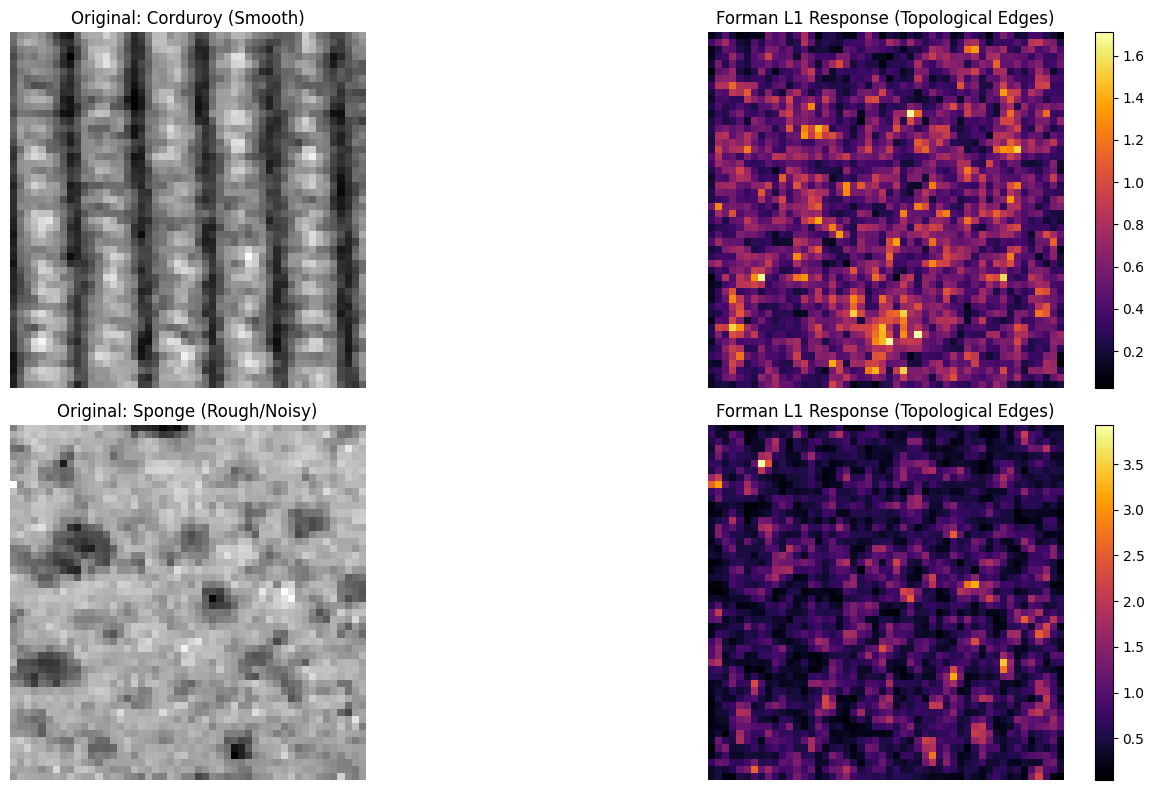

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import sparse
def pixel_index(r, c, W):
    """Flatten (row, col) to linear index."""
    return r * W + c

def build_forman_1_laplacian(H, W):
    """
    Builds the pure, unweighted Forman 1-Laplacian for an HxW grid.
    """
    num_h_edges = H * (W - 1)
    num_v_edges = (H - 1) * W
    num_edges   = num_h_edges + num_v_edges
    num_nodes   = H * W
    num_faces   = (H - 1) * (W - 1)

    def h_edge_idx(r, c):  return r * (W - 1) + c
    def v_edge_idx(r, c):  return num_h_edges + r * W + c
    def face_idx(r, c):    return r * (W - 1) + c

    # ── Build B1 (Nodes to Edges) ──
    b1_row, b1_col, b1_data = [], [], []
    for r in range(H):
        for c in range(W - 1):
            e = h_edge_idx(r, c)
            tail = pixel_index(r, c,     W)
            head = pixel_index(r, c + 1, W)
            b1_row += [tail, head]; b1_col += [e, e]; b1_data += [-1.0, 1.0]

    for r in range(H - 1):
        for c in range(W):
            e = v_edge_idx(r, c)
            tail = pixel_index(r,     c, W)
            head = pixel_index(r + 1, c, W)
            b1_row += [tail, head]; b1_col += [e, e]; b1_data += [-1.0, 1.0]

    B1 = sparse.csr_matrix((b1_data, (b1_row, b1_col)), shape=(num_nodes, num_edges))

    # ── Build B2 (Edges to Faces) ──
    b2_row, b2_col, b2_data = [], [], []
    for r in range(H - 1):
        for c in range(W - 1):
            f = face_idx(r, c)
            b2_row.append(h_edge_idx(r, c));     b2_col.append(f); b2_data.append(-1.0)
            b2_row.append(h_edge_idx(r + 1, c)); b2_col.append(f); b2_data.append(+1.0)
            b2_row.append(v_edge_idx(r, c));     b2_col.append(f); b2_data.append(-1.0)
            b2_row.append(v_edge_idx(r, c + 1)); b2_col.append(f); b2_data.append(+1.0)

    B2 = sparse.csr_matrix((b2_data, (b2_row, b2_col)), shape=(num_edges, num_faces))

    # ── Forman L1 = B1^T B1 + B2 B2^T ──
    L1 = B1.T @ B1 + B2 @ B2.T
    return L1.tocsr()

def apply_forman_to_image(img_path, n_size=50):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (n_size, n_size))
    H, W = img.shape
    pixels = img.flatten().astype(float) / 255.0

    # 1. Build the pure mathematical Forman Laplacian (depends only on grid size)
    L1 = build_forman_1_laplacian(H, W)

    # 2. Map Image (0-cells) to Edges (1-cells) -> Discrete Derivative
    num_h_edges = H * (W - 1)
    num_v_edges = (H - 1) * W
    edge_signal = np.zeros(num_h_edges + num_v_edges)

    idx = 0
    # Horizontal gradients
    for r in range(H):
        for c in range(W - 1):
            edge_signal[idx] = pixels[pixel_index(r, c+1, W)] - pixels[pixel_index(r, c, W)]
            idx += 1
    # Vertical gradients
    for r in range(H - 1):
        for c in range(W):
            edge_signal[idx] = pixels[pixel_index(r+1, c, W)] - pixels[pixel_index(r, c, W)]
            idx += 1

    # 3. Apply the Forman Operator (L1 * edges)
    # This highlights areas of topological discontinuity / negative curvature
    filtered_edges = L1 @ edge_signal

    # 4. Map back to Pixels for visualization (summing absolute edge values)
    result_img = np.zeros(H * W)
    idx = 0
    for r in range(H):
        for c in range(W - 1):
            val = abs(filtered_edges[idx])
            result_img[pixel_index(r, c, W)] += val
            result_img[pixel_index(r, c+1, W)] += val
            idx += 1
    for r in range(H - 1):
        for c in range(W):
            val = abs(filtered_edges[idx])
            result_img[pixel_index(r, c, W)] += val
            result_img[pixel_index(r+1, c, W)] += val
            idx += 1

    return img, result_img.reshape((H, W))

# ---- Visualization on two KTH-TIPS images ----
KTH_ROOT = "/content/drive/My Drive/Final Project (Applied mathmatic)/KTH-TIPS"
img_smooth_path = f"{KTH_ROOT}/corduroy/42-scale_1_im_1_grey.png"
img_rough_path  = f"{KTH_ROOT}/sponge/21-scale_1_im_1_grey.png"

orig_smooth, forman_smooth = apply_forman_to_image(img_smooth_path)
orig_rough,  forman_rough  = apply_forman_to_image(img_rough_path)

plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.imshow(orig_smooth, cmap='gray')
plt.title('Original: Corduroy (Smooth)')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(forman_smooth, cmap='inferno')
plt.title('Forman L1 Response (Topological Edges)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(orig_rough, cmap='gray')
plt.title('Original: Sponge (Rough/Noisy)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(forman_rough, cmap='inferno')
plt.title('Forman L1 Response (Topological Edges)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.tight_layout()
plt.show()

Computing eigenvalues for the pure unweighted Laplacian...


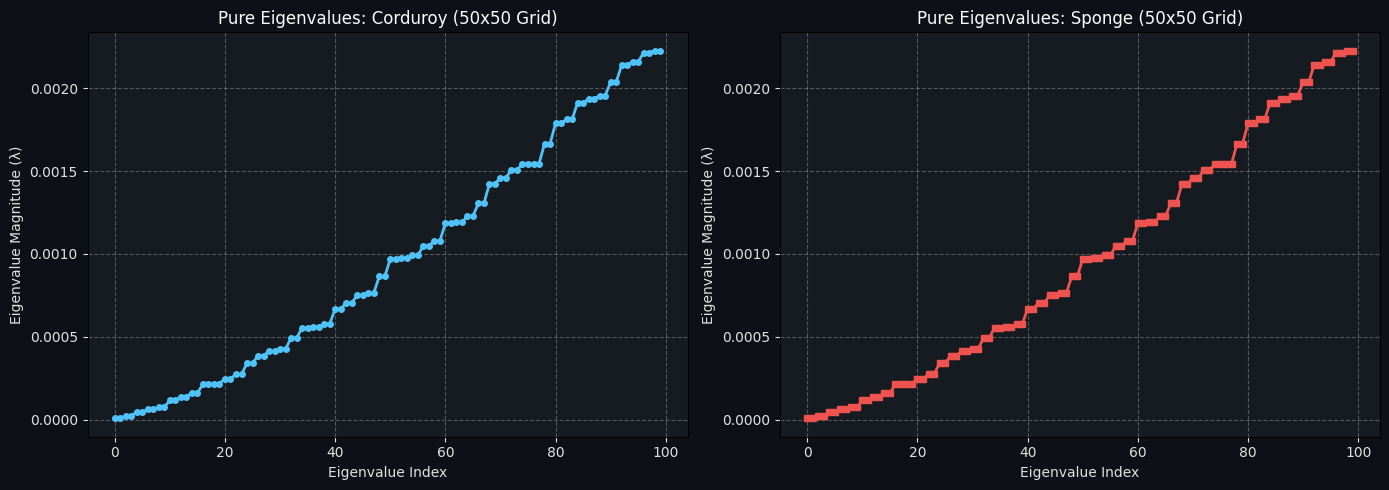

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# --- 1. בניית הלפלסיאן הטהור ---
# מכיוון ששתי התמונות עברו resize ל-50x50, שתיהן יושבות על אותו גריד בדיוק
H, W = 50, 50
L1_pure_sparse = build_forman_1_laplacian(H, W)
L1_pure_dense = L1_pure_sparse.toarray()

print("Computing eigenvalues for the pure unweighted Laplacian...")
# --- 2. חישוב הערכים העצמיים הטהורים ---
evals_pure = eigh(L1_pure_dense, eigvals_only=True)

# סינון ערכי האפס והשארת 100 התדרים המשמעותיים הראשונים
k = 100
evals_pure_filtered = evals_pure[evals_pure > 1e-8][:k]

# --- 3. ציור שני גרפים נפרדים לחלוטין ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# גרף 1: קורדרוי (על בסיס הלפלסיאן הטהור של התמונה)
ax1.plot(evals_pure_filtered, color='#4fc3f7', marker='o', markersize=4, linewidth=2)
ax1.set_title('Pure Eigenvalues: Corduroy (50x50 Grid)', color='#fafafa')
ax1.set_xlabel('Eigenvalue Index', color='#e0e0e0')
ax1.set_ylabel('Eigenvalue Magnitude (λ)', color='#e0e0e0')
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.set_facecolor('#161b22')
ax1.tick_params(colors='#e0e0e0')

# גרף 2: ספוג (על בסיס הלפלסיאן הטהור של התמונה)
# שים לב: אנחנו מעבירים את אותו מערך evals_pure_filtered כי אין שום משקל שמבדיל ביניהן
ax2.plot(evals_pure_filtered, color='#ef5350', marker='s', markersize=4, linewidth=2)
ax2.set_title('Pure Eigenvalues: Sponge (50x50 Grid)', color='#fafafa')
ax2.set_xlabel('Eigenvalue Index', color='#e0e0e0')
ax2.set_ylabel('Eigenvalue Magnitude (λ)', color='#e0e0e0')
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.set_facecolor('#161b22')
ax2.tick_params(colors='#e0e0e0')

fig.patch.set_facecolor('#0d1117')
plt.tight_layout()
plt.show()

Computing eigenvalues for Weighted Laplacians...


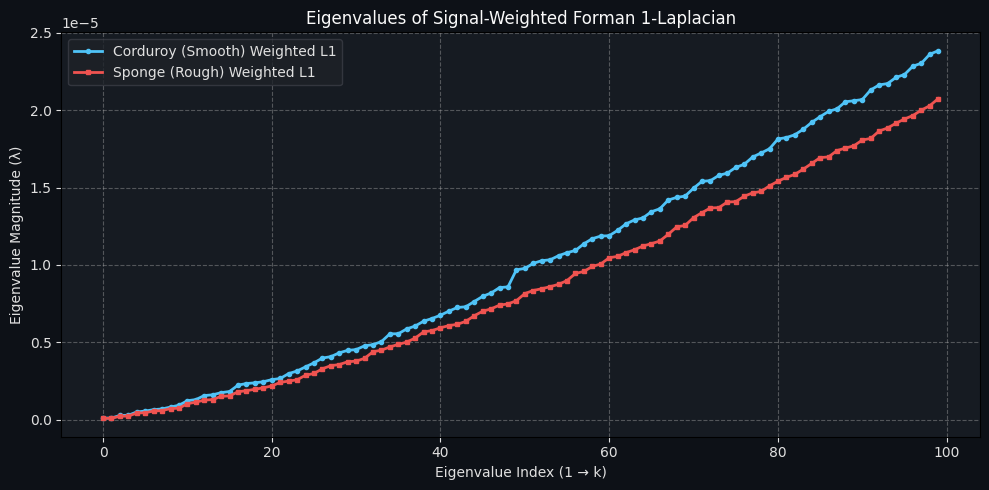

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
import scipy.sparse as sparse
import cv2
def extract_edge_signal(img_path, H=50, W=50):
    """
    קוראת תמונה, משנה את גודלה ומחשבת את הנגזרות הדיסקרטיות
    (הפרשי הפיקסלים) על כל הצלעות האופקיות והאנכיות.
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    # שים לב: cv2.resize מקבלת (רוחב, גובה)
    img = cv2.resize(img, (W, H))
    pixels = img.flatten().astype(float) / 255.0

    num_h_edges = H * (W - 1)
    num_v_edges = (H - 1) * W
    edge_signal = np.zeros(num_h_edges + num_v_edges)

    idx = 0
    # חישוב גרדיאנטים אופקיים
    for r in range(H):
        for c in range(W - 1):
            edge_signal[idx] = pixels[pixel_index(r, c+1, W)] - pixels[pixel_index(r, c, W)]
            idx += 1

    # חישוב גרדיאנטים אנכיים
    for r in range(H - 1):
        for c in range(W):
            edge_signal[idx] = pixels[pixel_index(r+1, c, W)] - pixels[pixel_index(r, c, W)]
            idx += 1

    return edge_signal

# אני מניח שהפונקציות build_forman_1_laplacian ו-extract_edge_signal כבר מוגדרות אצלך
# (כמו בקודים הקודמים שכתבנו)

# 1. בניית הלפלסיאן הטהור (הבסיס הגיאומטרי)
H, W_grid = 50, 50
L1_pure = build_forman_1_laplacian(H, W_grid)

# 2. חילוץ אותות התמונה (הגרדיאנטים על הצלעות)
signal_smooth = extract_edge_signal(img_smooth_path, H, W_grid)
signal_rough  = extract_edge_signal(img_rough_path, H, W_grid)

# 3. בניית מטריצות משקלים אלכסוניות (W)
# נוסיף אפסילון קטן (1e-3) כדי למנוע איפוס מוחלט של צלעות שאין בהן שינוי כלל
eps = 1e-3
w_smooth = np.sqrt(np.abs(signal_smooth) + eps)
w_rough  = np.sqrt(np.abs(signal_rough) + eps)

W_mat_smooth = sparse.diags(w_smooth)
W_mat_rough  = sparse.diags(w_rough)

# 4. יצירת מטריצות הלפלסיאן הממושקלות (Signal-Weighted Laplacian)
L1_w_smooth = W_mat_smooth @ L1_pure @ W_mat_smooth
L1_w_rough  = W_mat_rough @ L1_pure @ W_mat_rough

# 5. חישוב הערכים העצמיים
print("Computing eigenvalues for Weighted Laplacians...")
ev_smooth = eigh(L1_w_smooth.toarray(), eigvals_only=True)
ev_rough  = eigh(L1_w_rough.toarray(), eigvals_only=True)

# סינון אפסים ולקיחת ה-k הראשונים (תדרים משמעותיים)
k = 100
ev_smooth = ev_smooth[ev_smooth > 1e-8][:k]
ev_rough  = ev_rough[ev_rough > 1e-8][:k]

# 6. ציור הגרף
plt.figure(figsize=(10, 5))
plt.plot(ev_smooth, color='#4fc3f7', marker='o', markersize=3, linewidth=2, label='Corduroy (Smooth) Weighted L1')
plt.plot(ev_rough,  color='#ef5350', marker='s', markersize=3, linewidth=2, label='Sponge (Rough) Weighted L1')

plt.title('Eigenvalues of Signal-Weighted Forman 1-Laplacian', color='#fafafa')
plt.xlabel('Eigenvalue Index (1 → k)', color='#e0e0e0')
plt.ylabel('Eigenvalue Magnitude (λ)', color='#e0e0e0')
plt.legend(facecolor='#1e2228', edgecolor='#3a3d45', labelcolor='#e0e0e0')
plt.grid(True, linestyle='--', alpha=0.4)

# עיצוב כהה
plt.gca().set_facecolor('#161b22')
plt.gcf().patch.set_facecolor('#0d1117')
plt.gca().tick_params(colors='#e0e0e0')

plt.tight_layout()
plt.show()

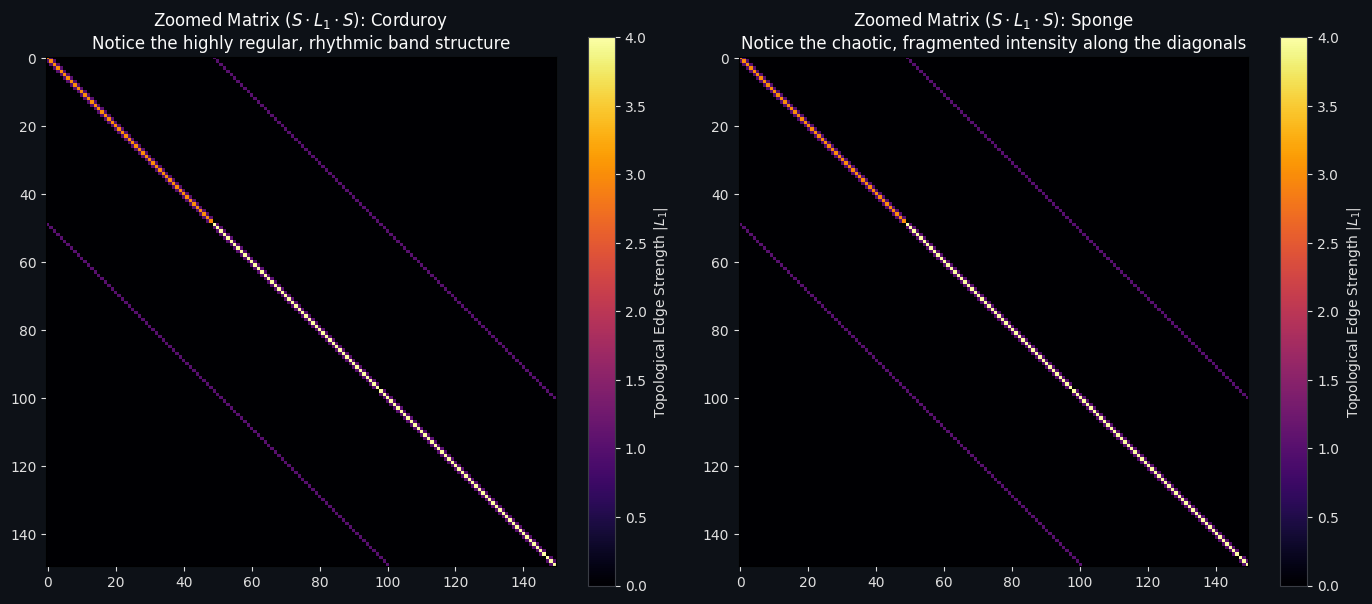

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import sparse

def get_forman_matrix_zoomed(img_path, H=50, W=50, zoom_size=150):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image at {img_path}")

    img = cv2.resize(img, (W, H))
    f = img.flatten().astype(float) / 255.0
    f = np.clip(f, 0.01, None)

    num_h_edges = H * (W - 1)
    num_v_edges = (H - 1) * W
    edge_f = np.zeros(num_h_edges + num_v_edges)

    idx = 0
    for r in range(H):
        for c in range(W - 1):
            edge_f[idx] = 0.5 * (f[pixel_index(r, c, W)] + f[pixel_index(r, c+1, W)])
            idx += 1
    for r in range(H - 1):
        for c in range(W):
            edge_f[idx] = 0.5 * (f[pixel_index(r, c, W)] + f[pixel_index(r+1, c, W)])
            idx += 1

    L1_pure = build_forman_1_laplacian(H, W)
    S = sparse.diags(np.sqrt(edge_f))
    L1_weighted = (S @ L1_pure @ S).tocsr()

    # מחזירים את הערך המוחלט של המטריצה באזור הזום כדי להדגיש את עוצמת הקשר
    # (הערכים השליליים במטריצה הם רק עניין של אוריינטציית הצלעות)
    zoomed_block = np.abs(L1_pure.toarray()[:zoom_size, :zoom_size])
    return zoomed_block

# ==========================================
# הרצה והצגת ה"זום-אין"
# ==========================================

KTH_ROOT = "/content/drive/My Drive/Final Project (Applied mathmatic)/KTH-TIPS"
img_smooth_path = f"{KTH_ROOT}/corduroy/42-scale_1_im_1_grey.png"
img_rough_path  = f"{KTH_ROOT}/sponge/21-scale_1_im_1_grey.png"

# חיתוך בלוק של 150x150
zoom_size = 150
L1_smooth_zoomed = get_forman_matrix_zoomed(img_smooth_path, H=50, W=50, zoom_size=zoom_size)
L1_rough_zoomed  = get_forman_matrix_zoomed(img_rough_path,  H=50, W=50, zoom_size=zoom_size)

# 3. ציור מחדש בצורה בטוחה
fig = plt.figure(figsize=(14, 6))

# קורדרוי
ax1 = fig.add_subplot(1, 2, 1)
im1 = ax1.imshow(L1_smooth_zoomed, cmap='inferno', interpolation='none')
cb1 = plt.colorbar(im1, ax=ax1)
# הוספנו r לפני המחרוזת כדי שפייתון יבין שזה LaTeX
ax1.set_title(r'Zoomed Matrix ($S \cdot L_1 \cdot S$): Corduroy' + '\nNotice the highly regular, rhythmic band structure')

# ספוג
ax2 = fig.add_subplot(1, 2, 2)
im2 = ax2.imshow(L1_rough_zoomed, cmap='inferno', interpolation='none')
cb2 = plt.colorbar(im2, ax=ax2)
ax2.set_title(r'Zoomed Matrix ($S \cdot L_1 \cdot S$): Sponge' + '\nNotice the chaotic, fragmented intensity along the diagonals')

# עיצוב מודרני כהה - בצורה בטוחה שלא מוחקת את הגרפים
fig.patch.set_facecolor('#0d1117')
for ax, cb in zip([ax1, ax2], [cb1, cb2]):
    # צביעת הצירים והכותרות
    ax.tick_params(colors='#e0e0e0')
    ax.title.set_color('#fafafa')
    ax.xaxis.label.set_color('#e0e0e0')
    ax.yaxis.label.set_color('#e0e0e0')

    # צביעת ה-Colorbar
    cb.ax.yaxis.set_tick_params(color='#e0e0e0')
    cb.outline.set_edgecolor('#3a3d45')
    plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color='#e0e0e0')
    cb.set_label(r'Topological Edge Strength $|L_1|$', color='#e0e0e0')

plt.tight_layout()
plt.show()

Building Forman 1-Laplacian matrix...
Computing Forman 1-Laplacian heat diffusion for:
Forman Heat Diffusion: Corduroy (Smooth)...
  - Calculating dense eigensystem (takes a few seconds)...


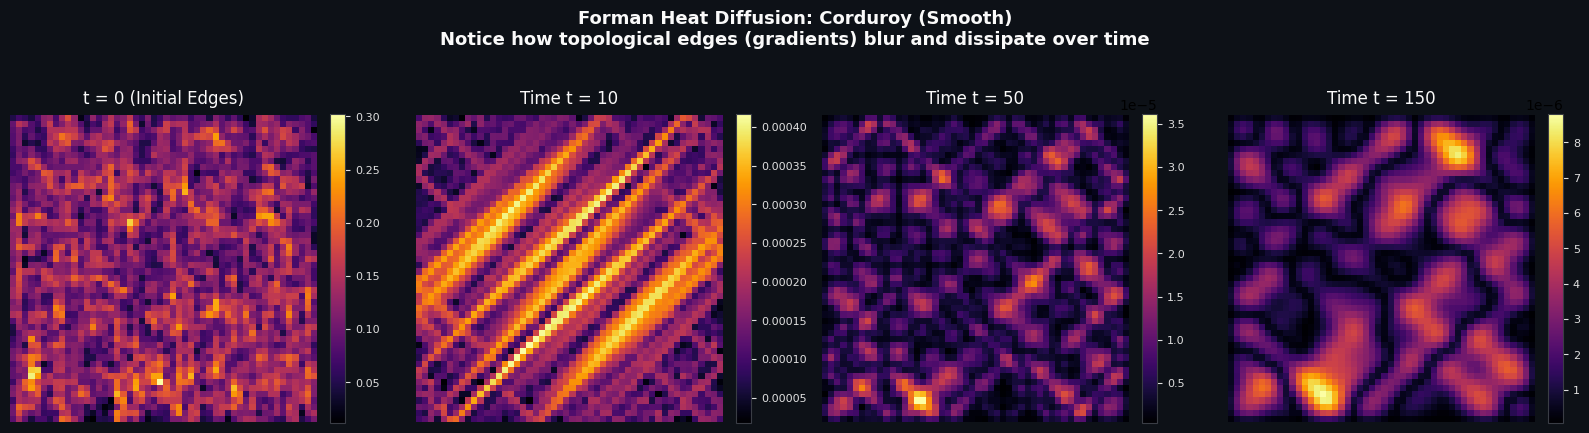

Computing Forman 1-Laplacian heat diffusion for:
Forman Heat Diffusion: Sponge (Rough)...
  - Calculating dense eigensystem (takes a few seconds)...


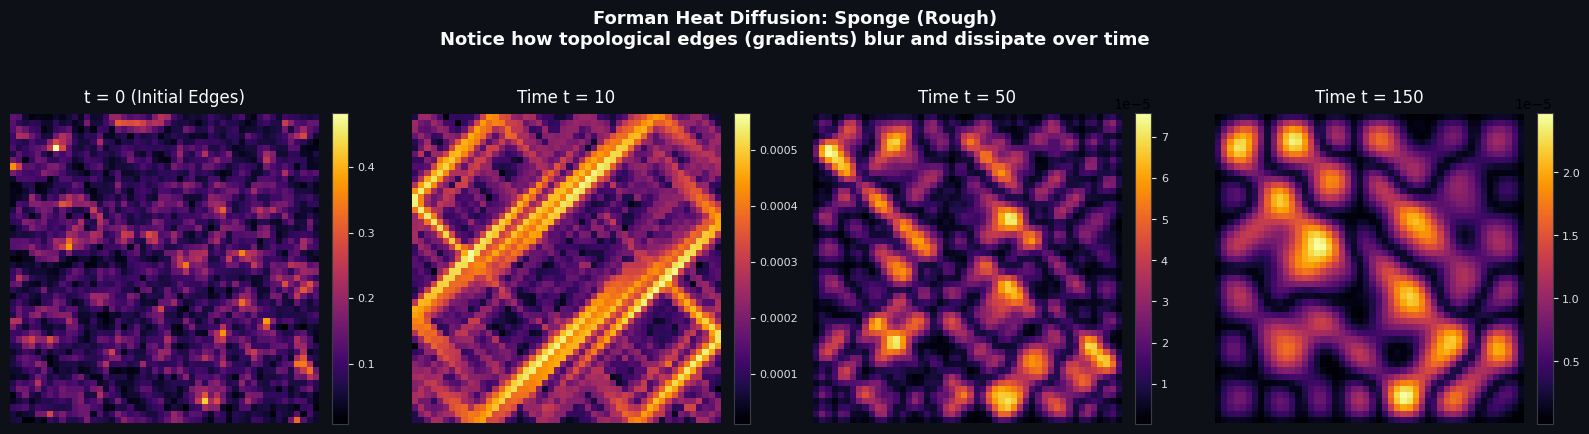

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.linalg import eigh

# ==========================================
# 1. בניית הלפלסיאן של פורמן (L1)
# ==========================================

# ==========================================
# 2. סימולציית דיפוזיית חום ספקטרלית על צלעות (Forman)
# ==========================================

def compute_forman_heat_diffusion(L1_sparse, img_pixels, H, W, c, times):
    """
    מבצע דיפוזיית חום על הצלעות ומשחזר חזרה לפיקסלים (באנרגיה מוחלטת).
    """
    # שלב א': חילוץ ערכים וקטורים עצמיים (Dense)
    print("  - Calculating dense eigensystem (takes a few seconds)...")
    L1_dense = L1_sparse.toarray()
    vals, vecs = eigh(L1_dense)

    # שלב ב': המרת התמונה לאותות של צלעות (גרדיאנטים) - זה ה-φ(0) שלנו
    num_h_edges = H * (W - 1)
    num_v_edges = (H - 1) * W
    edge_signal = np.zeros(num_h_edges + num_v_edges)

    idx = 0
    # גרדיאנטים אופקיים
    for r in range(H):
        for c in range(W - 1):
            edge_signal[idx] = img_pixels[pixel_index(r, c+1, W)] - img_pixels[pixel_index(r, c, W)]
            idx += 1
    # גרדיאנטים אנכיים
    for r in range(H - 1):
        for c in range(W):
            edge_signal[idx] = img_pixels[pixel_index(r+1, c, W)] - img_pixels[pixel_index(r, c, W)]
            idx += 1

    # הטלה לבסיס הספקטרלי
    alpha = vecs.T @ edge_signal

    # שלב ג': דיפוזיה בזמן ושחזור התמונה
    result_images = {}
    for t in times:
        # חום הצלעות בזמן t
        decay = np.exp(-c * t * vals)
        edges_t = vecs @ (decay * alpha)

        # המרה חזרה לפיקסלים: סכימת העוצמה (ערך מוחלט) של הצלעות שנוגעות בפיקסל
        pixel_energy = np.zeros(H * W)
        idx = 0
        for r in range(H):
            for c in range(W - 1):
                val = abs(edges_t[idx])
                pixel_energy[pixel_index(r, c, W)] += val
                pixel_energy[pixel_index(r, c+1, W)] += val
                idx += 1
        for r in range(H - 1):
            for c in range(W):
                val = abs(edges_t[idx])
                pixel_energy[pixel_index(r, c, W)] += val
                pixel_energy[pixel_index(r+1, c, W)] += val
                idx += 1

        result_images[t] = pixel_energy.reshape((H, W))

    return result_images

def plot_forman_heat_diffusion(L1, img_path, title, H=50, W=50, c=0.05):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (W, H))
    pixels = img.flatten().astype(float) / 255.0

    times = [0, 10, 50, 150]

    print(f"Computing Forman 1-Laplacian heat diffusion for:\n{title}...")
    diff_snapshots = compute_forman_heat_diffusion(L1, pixels, H, W, c, times)

    # ציור
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle(title + "\nNotice how topological edges (gradients) blur and dissipate over time",
                 color='#fafafa', fontsize=13, fontweight='bold', y=1.08)

    for i, t in enumerate(times):
        ax = axes[i]
        phi_t_grid = diff_snapshots[t]

        # התיקון: נרמול דינמי לכל חלון זמן בנפרד!
        # כיוון שהגרדיאנטים דועכים לאפס, נעדכן את טווח הצבעים כדי לראות את המבנה שלהם
        vmin, vmax = phi_t_grid.min(), phi_t_grid.max()

        im = ax.imshow(phi_t_grid, cmap='inferno', vmin=vmin, vmax=vmax, interpolation='nearest')

        title_str = f'Time t = {t}' if t > 0 else 't = 0 (Initial Edges)'
        ax.set_title(title_str, color='#fafafa', pad=8)
        ax.axis('off')

        # אנחנו מדפיסים Colorbar לכל גרף כדי שתוכל לראות איך הערכים (vmax) צונחים לאפס
        cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cb.ax.yaxis.set_tick_params(color='#e0e0e0', labelsize=8)
        cb.outline.set_edgecolor('#3a3d45')
        plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color='#e0e0e0')

    plt.tight_layout()
    plt.show()

# ==========================================
# 3. הרצה
# ==========================================

KTH_ROOT = "/content/drive/My Drive/Final Project (Applied mathmatic)/KTH-TIPS"
img_smooth_path = f"{KTH_ROOT}/corduroy/42-scale_1_im_1_grey.png"
img_rough_path  = f"{KTH_ROOT}/sponge/21-scale_1_im_1_grey.png"

H_size, W_size = 50, 50

print("Building Forman 1-Laplacian matrix...")
L1_pure = build_forman_1_laplacian(H_size, W_size)

plot_forman_heat_diffusion(L1_pure, img_smooth_path, "Forman Heat Diffusion: Corduroy (Smooth)", H=H_size, W=W_size)
plot_forman_heat_diffusion(L1_pure, img_rough_path,  "Forman Heat Diffusion: Sponge (Rough)", H=H_size, W=W_size)

##Forman Laplacian 2D

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


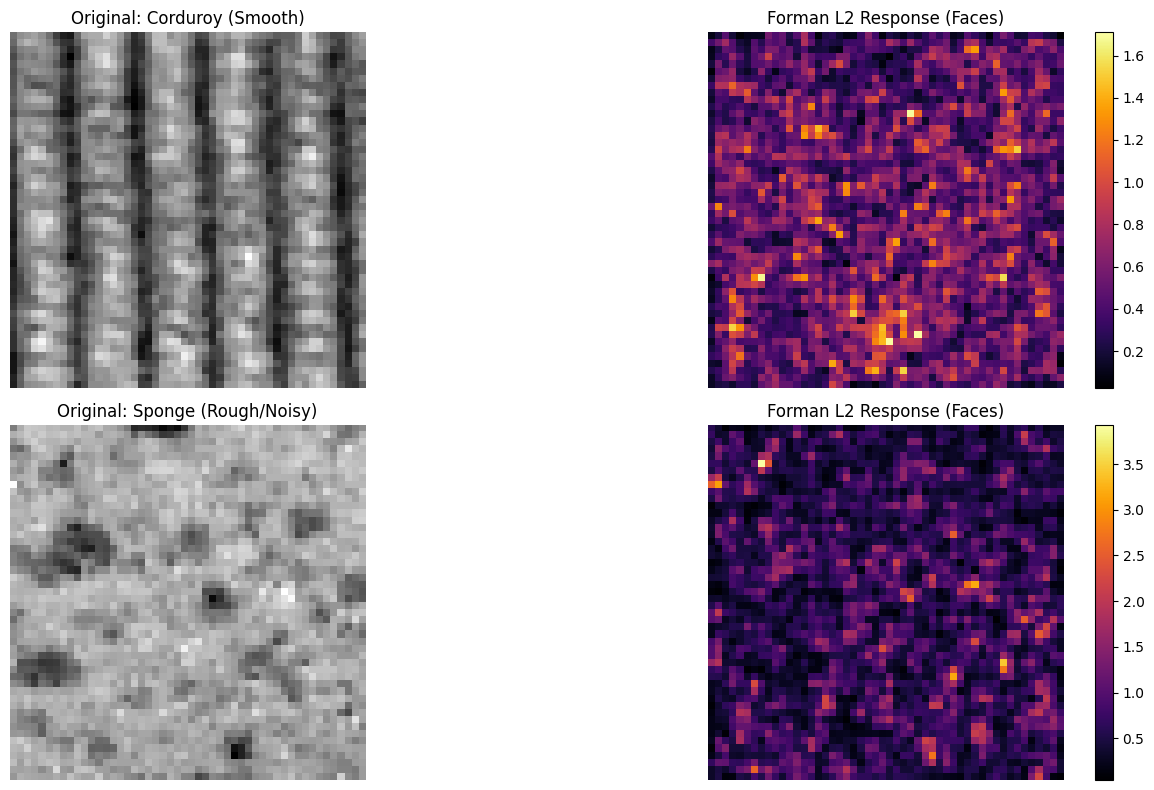

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import sparse
from google.colab import drive

drive.mount('/content/drive')

# ==========================================
# 1. בניית הלפלסיאן הדו-ממדי של פורמן (2-Laplacian)
# ==========================================

def build_forman_2_laplacian(H, W):
    """
    Builds the pure, unweighted Forman 2-Laplacian for an HxW grid of faces (pixels).
    L2 = B2^T @ B2
    """
    num_faces = H * W

    # In a grid where pixels are faces, we have (H+1) vertical lines and (W+1) horizontal lines
    num_h_edges = (H + 1) * W
    num_v_edges = H * (W + 1)
    num_edges = num_h_edges + num_v_edges

    def h_edge_idx(r, c):  return r * W + c
    def v_edge_idx(r, c):  return num_h_edges + r * (W + 1) + c
    def face_idx(r, c):    return r * W + c

    # ── Build B2 (Edges to Faces) ──
    b2_row, b2_col, b2_data = [], [], []
    for r in range(H):
        for c in range(W):
            f = face_idx(r, c)
            # Top edge
            b2_row.append(h_edge_idx(r, c));     b2_col.append(f); b2_data.append(-1.0)
            # Bottom edge
            b2_row.append(h_edge_idx(r + 1, c)); b2_col.append(f); b2_data.append(+1.0)
            # Left edge
            b2_row.append(v_edge_idx(r, c));     b2_col.append(f); b2_data.append(-1.0)
            # Right edge
            b2_row.append(v_edge_idx(r, c + 1)); b2_col.append(f); b2_data.append(+1.0)

    B2 = sparse.csr_matrix((b2_data, (b2_row, b2_col)), shape=(num_edges, num_faces))

    # ── Forman 2-Laplacian L2 = B2^T B2 ──
    L2 = B2.T @ B2
    return L2.tocsr()


def apply_forman_2_to_image(img_path, n_size=50):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (n_size, n_size))
    H, W = img.shape

    # The pixels are the faces (2-cells), so this is our input signal directly
    pixels = img.flatten().astype(float) / 255.0

    # 1. Build the Forman 2-Laplacian
    L2 = build_forman_2_laplacian(H, W)

    # 2. Apply the Forman Operator (L2 * faces)
    # This highlights areas where a pixel differs significantly from its neighbors
    filtered_faces = L2 @ pixels

    # 3. Reshape back to image dimensions (taking absolute value for visualization)
    result_img = np.abs(filtered_faces).reshape((H, W))

    return img, result_img

# ---- Visualization on two KTH-TIPS images ----
KTH_ROOT = "/content/drive/My Drive/Final Project (Applied mathmatic)/KTH-TIPS"
img_smooth_path = f"{KTH_ROOT}/corduroy/42-scale_1_im_1_grey.png"
img_rough_path  = f"{KTH_ROOT}/sponge/21-scale_1_im_1_grey.png"

orig_smooth, forman2_smooth = apply_forman_2_to_image(img_smooth_path)
orig_rough,  forman2_rough  = apply_forman_2_to_image(img_rough_path)

plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.imshow(orig_smooth, cmap='gray')
plt.title('Original: Corduroy (Smooth)')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(forman_smooth, cmap='inferno')
plt.title('Forman L2 Response (Faces)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(orig_rough, cmap='gray')
plt.title('Original: Sponge (Rough/Noisy)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(forman_rough, cmap='inferno')
plt.title('Forman L2 Response (Faces)')
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.tight_layout()
plt.show()

Computing eigenvalues for Forman 2-Laplacian (this might take a few seconds)...


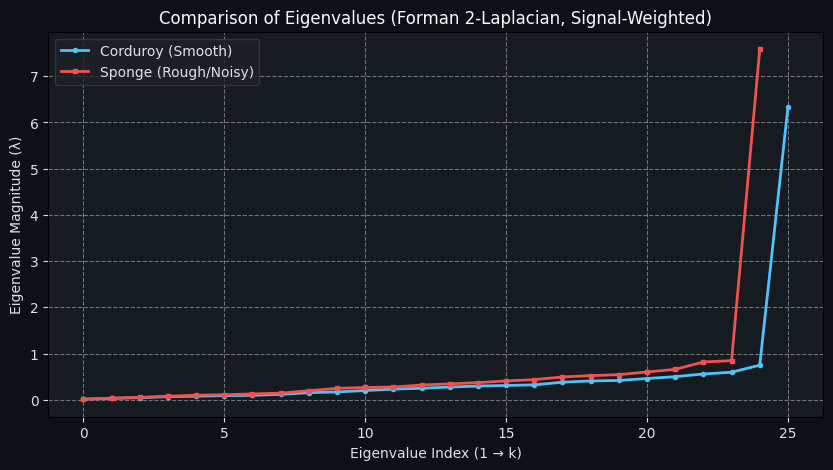

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.linalg import eigh

# ==========================================
# 1. בניית אופרטור פורמן הדו-ממדי הטהור (2-Laplacian)
# ==========================================

def build_forman_2_laplacian(H, W):
    """
    Builds the pure, unweighted Forman 2-Laplacian for an HxW grid of faces (pixels).
    L2 = B2^T @ B2
    """
    num_faces = H * W
    num_h_edges = (H + 1) * W
    num_v_edges = H * (W + 1)
    num_edges = num_h_edges + num_v_edges

    def h_edge_idx(r, c):  return r * W + c
    def v_edge_idx(r, c):  return num_h_edges + r * (W + 1) + c
    def face_idx(r, c):    return r * W + c

    # ── Build B2 (Edges to Faces) ──
    b2_row, b2_col, b2_data = [], [], []
    for r in range(H):
        for c in range(W):
            f = face_idx(r, c)
            # Top edge
            b2_row.append(h_edge_idx(r, c));     b2_col.append(f); b2_data.append(-1.0)
            # Bottom edge
            b2_row.append(h_edge_idx(r + 1, c)); b2_col.append(f); b2_data.append(+1.0)
            # Left edge
            b2_row.append(v_edge_idx(r, c));     b2_col.append(f); b2_data.append(-1.0)
            # Right edge
            b2_row.append(v_edge_idx(r, c + 1)); b2_col.append(f); b2_data.append(+1.0)

    B2 = sparse.csr_matrix((b2_data, (b2_row, b2_col)), shape=(num_edges, num_faces))
    L2 = B2.T @ B2
    return L2.tocsr()


# ==========================================
# 3. חילוץ הערכים העצמיים (Spectrum)
# ==========================================
k = 100
print("Computing eigenvalues for Forman 2-Laplacian (this might take a few seconds)...")

# המרה למטריצה צפופה עבור הסולבר הבטוח eigh
# ממדי המטריצה הם 2500x2500 (מספר הפיקסלים)
ev_smooth = eigh(forman2_smooth, eigvals_only=True)
ev_rough  = eigh(forman2_rough,  eigvals_only=True)

# סינון ערכי האפס (Null-space טופולוגי) כדי להשאיר רק תדרים משמעותיים
ev_smooth = ev_smooth[ev_smooth > 1e-8][:k]
ev_rough  = ev_rough[ev_rough > 1e-8][:k]

# ==========================================
# 4. ציור גרף הספקטרום
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(ev_smooth, color='#4fc3f7', marker='o', markersize=3, linewidth=2, label='Corduroy (Smooth)')
plt.plot(ev_rough,  color='#ef5350', marker='s', markersize=3, linewidth=2, label='Sponge (Rough/Noisy)')

plt.xlabel('Eigenvalue Index (1 → k)')
plt.ylabel('Eigenvalue Magnitude (λ)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# התאמת עיצוב כהה ומקצועי (Dark Mode)
plt.gca().set_facecolor('#161b22')
plt.gcf().patch.set_facecolor('#0d1117')
plt.gca().tick_params(colors='#e0e0e0')
plt.gca().xaxis.label.set_color('#e0e0e0')
plt.gca().yaxis.label.set_color('#e0e0e0')
plt.title('Comparison of Eigenvalues (Forman 2-Laplacian, Signal-Weighted)', color='#fafafa')
plt.legend(facecolor='#1e2228', edgecolor='#3a3d45', labelcolor='#e0e0e0')

plt.show()

Computing eigenvalues for the pure unweighted 2-Laplacian...


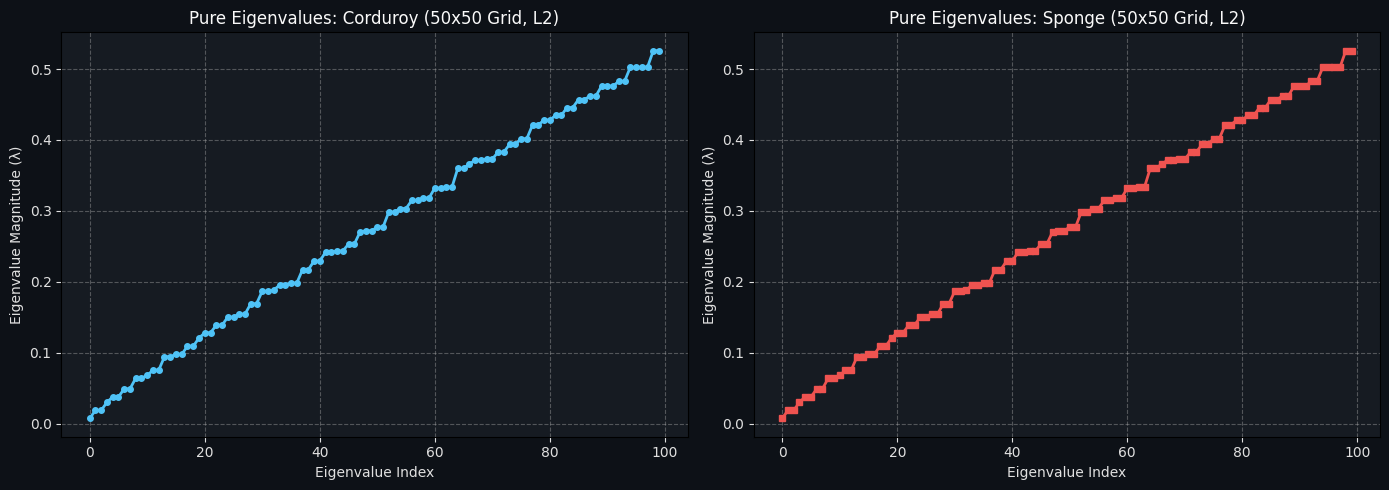

Computing eigenvalues for Signal-Weighted 2-Laplacians...


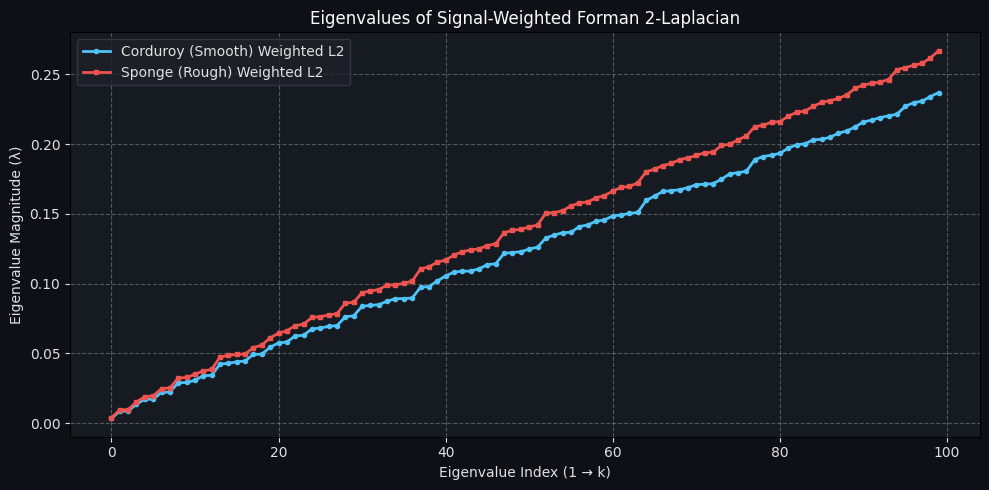

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.linalg import eigh

# ==========================================
# 1. בניית הלפלסיאן הדו-ממדי הטהור (2-Laplacian)
# ==========================================
def build_forman_2_laplacian(H, W):
    """
    Builds the pure, unweighted Forman 2-Laplacian for an HxW grid of faces (pixels).
    L2 = B2^T @ B2
    """
    num_faces = H * W
    num_h_edges = (H + 1) * W
    num_v_edges = H * (W + 1)
    num_edges = num_h_edges + num_v_edges

    def h_edge_idx(r, c):  return r * W + c
    def v_edge_idx(r, c):  return num_h_edges + r * (W + 1) + c
    def face_idx(r, c):    return r * W + c

    b2_row, b2_col, b2_data = [], [], []
    for r in range(H):
        for c in range(W):
            f = face_idx(r, c)
            # Top edge
            b2_row.append(h_edge_idx(r, c));     b2_col.append(f); b2_data.append(-1.0)
            # Bottom edge
            b2_row.append(h_edge_idx(r + 1, c)); b2_col.append(f); b2_data.append(+1.0)
            # Left edge
            b2_row.append(v_edge_idx(r, c));     b2_col.append(f); b2_data.append(-1.0)
            # Right edge
            b2_row.append(v_edge_idx(r, c + 1)); b2_col.append(f); b2_data.append(+1.0)

    B2 = sparse.csr_matrix((b2_data, (b2_row, b2_col)), shape=(num_edges, num_faces))

    # L2 = B2^T B2 (פועל על הפאות/הפיקסלים)
    L2 = B2.T @ B2
    return L2.tocsr()

# ==========================================
# הגדרות כלליות וטעינת נתונים
# ==========================================
H, W_grid = 50, 50
k = 100
KTH_ROOT = "/content/drive/My Drive/Final Project (Applied mathmatic)/KTH-TIPS"
img_smooth_path = f"{KTH_ROOT}/corduroy/42-scale_1_im_1_grey.png"
img_rough_path  = f"{KTH_ROOT}/sponge/21-scale_1_im_1_grey.png"

def get_face_signal(img_path, H, W):
    """ הפונקציה הרבה יותר פשוטה כאן כי האות הוא הפיקסלים עצמם """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (W, H))
    return img.flatten().astype(float) / 255.0

# חילוץ האותות (הפיקסלים)
signal_smooth = get_face_signal(img_smooth_path, H, W_grid)
signal_rough  = get_face_signal(img_rough_path, H, W_grid)

# ==========================================
# 2. חישוב וציור הלפלסיאן הטהור (Pure 2-Laplacian)
# ==========================================
print("Computing eigenvalues for the pure unweighted 2-Laplacian...")
L2_pure = build_forman_2_laplacian(H, W_grid)
evals_pure = eigh(L2_pure.toarray(), eigvals_only=True)

# סינון אפסים
evals_pure_filtered = evals_pure[evals_pure > 1e-8][:k]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# גרף תמונה חלקה - טהור
ax1.plot(evals_pure_filtered, color='#4fc3f7', marker='o', markersize=4, linewidth=2)
ax1.set_title('Pure Eigenvalues: Corduroy (50x50 Grid, L2)', color='#fafafa')
ax1.set_xlabel('Eigenvalue Index', color='#e0e0e0')
ax1.set_ylabel('Eigenvalue Magnitude (λ)', color='#e0e0e0')
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.set_facecolor('#161b22')
ax1.tick_params(colors='#e0e0e0')

# גרף תמונה רועשת - טהור (אותו המערך בדיוק)
ax2.plot(evals_pure_filtered, color='#ef5350', marker='s', markersize=4, linewidth=2)
ax2.set_title('Pure Eigenvalues: Sponge (50x50 Grid, L2)', color='#fafafa')
ax2.set_xlabel('Eigenvalue Index', color='#e0e0e0')
ax2.set_ylabel('Eigenvalue Magnitude (λ)', color='#e0e0e0')
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.set_facecolor('#161b22')
ax2.tick_params(colors='#e0e0e0')

fig.patch.set_facecolor('#0d1117')
plt.tight_layout()
plt.show()

# ==========================================
# 3. חישוב וציור הלפלסיאן הממושקל (Signal-Weighted 2-Laplacian)
# ==========================================
print("Computing eigenvalues for Signal-Weighted 2-Laplacians...")
eps = 1e-3

# בניית מטריצת המשקלים האלכסונית מתוך עוצמת הפיקסלים
W_mat_smooth = sparse.diags(np.sqrt(signal_smooth + eps))
W_mat_rough  = sparse.diags(np.sqrt(signal_rough + eps))

# הכפלת הלפלסיאן הטהור במשקלים: W * L2 * W
L2_w_smooth = W_mat_smooth @ L2_pure @ W_mat_smooth
L2_w_rough  = W_mat_rough @ L2_pure @ W_mat_rough

# חישוב ערכים עצמיים למטריצות הממושקלות
ev_smooth = eigh(L2_w_smooth.toarray(), eigvals_only=True)
ev_rough  = eigh(L2_w_rough.toarray(), eigvals_only=True)

# סינון תדרים משמעותיים
ev_smooth = ev_smooth[ev_smooth > 1e-8][:k]
ev_rough  = ev_rough[ev_rough > 1e-8][:k]

plt.figure(figsize=(10, 5))
plt.plot(ev_smooth, color='#4fc3f7', marker='o', markersize=3, linewidth=2, label='Corduroy (Smooth) Weighted L2')
plt.plot(ev_rough,  color='#ef5350', marker='s', markersize=3, linewidth=2, label='Sponge (Rough) Weighted L2')

plt.title('Eigenvalues of Signal-Weighted Forman 2-Laplacian', color='#fafafa')
plt.xlabel('Eigenvalue Index (1 → k)', color='#e0e0e0')
plt.ylabel('Eigenvalue Magnitude (λ)', color='#e0e0e0')
plt.legend(facecolor='#1e2228', edgecolor='#3a3d45', labelcolor='#e0e0e0')
plt.grid(True, linestyle='--', alpha=0.4)
plt.gca().set_facecolor('#161b22')
plt.gcf().patch.set_facecolor('#0d1117')
plt.gca().tick_params(colors='#e0e0e0')

plt.tight_layout()
plt.show()

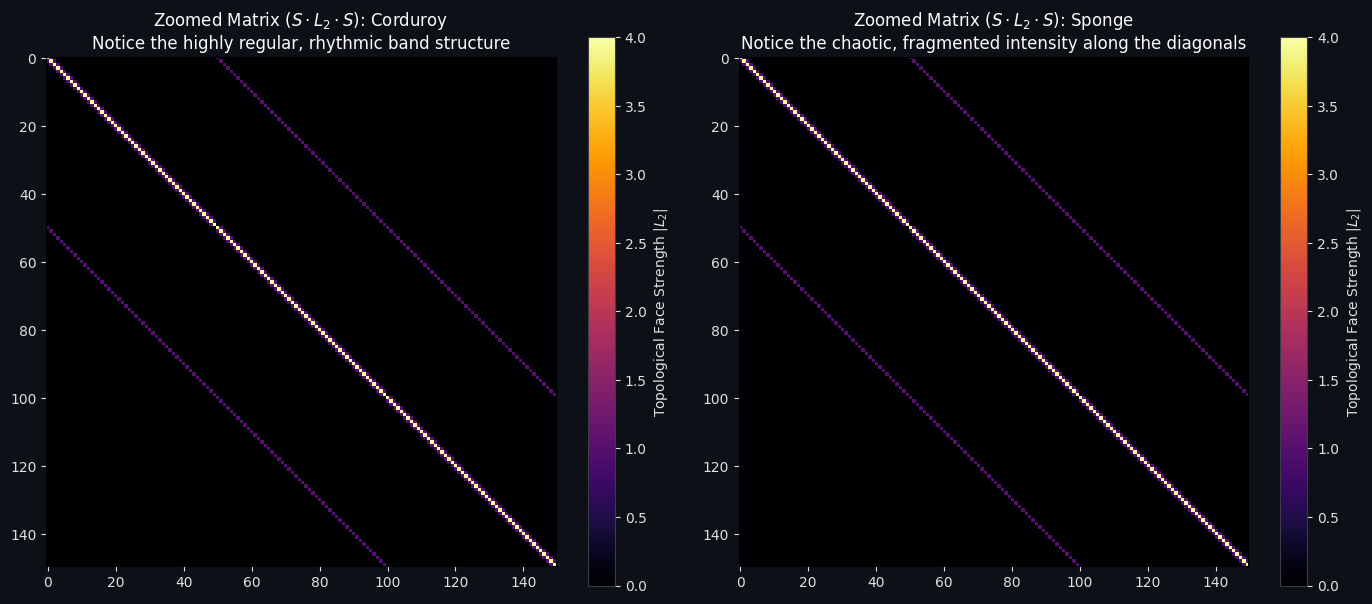

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import sparse

# ==========================================
# 1. בניית הלפלסיאן הדו-ממדי של פורמן (2-Laplacian)
# ==========================================

def get_forman_2_matrix_zoomed(img_path, H=50, W=50, zoom_size=150):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image at {img_path}")

    img = cv2.resize(img, (W, H))
    f = img.flatten().astype(float) / 255.0
    f = np.clip(f, 0.01, None)

    # בניית האופרטור הטהור
    L2_pure = build_forman_2_laplacian(H, W)

    # ב-2-Laplacian, האות מוטמע ישירות מהפיקסלים (הפנים)
    S = sparse.diags(np.sqrt(f))

    # חיתוך המטריצה ולקיחת ערך מוחלט להמחשת עצמת הקשר (ללא תלות באוריינטציה השלילית)
    zoomed_block = np.abs(L2_pure.toarray()[:zoom_size, :zoom_size])
    return zoomed_block

# ==========================================
# הרצה והצגת ה"זום-אין"
# ==========================================

KTH_ROOT = "/content/drive/My Drive/Final Project (Applied mathmatic)/KTH-TIPS"
img_smooth_path = f"{KTH_ROOT}/corduroy/42-scale_1_im_1_grey.png"
img_rough_path  = f"{KTH_ROOT}/sponge/21-scale_1_im_1_grey.png"

# חיתוך בלוק של 150x150
zoom_size = 150
L2_smooth_zoomed = get_forman_2_matrix_zoomed(img_smooth_path, H=50, W=50, zoom_size=zoom_size)
L2_rough_zoomed  = get_forman_2_matrix_zoomed(img_rough_path,  H=50, W=50, zoom_size=zoom_size)

# ציור
fig = plt.figure(figsize=(14, 6))

# קורדרוי
ax1 = fig.add_subplot(1, 2, 1)
im1 = ax1.imshow(L2_smooth_zoomed, cmap='inferno', interpolation='none')
cb1 = plt.colorbar(im1, ax=ax1)
ax1.set_title(r'Zoomed Matrix ($S \cdot L_2 \cdot S$): Corduroy' + '\nNotice the highly regular, rhythmic band structure')

# ספוג
ax2 = fig.add_subplot(1, 2, 2)
im2 = ax2.imshow(L2_rough_zoomed, cmap='inferno', interpolation='none')
cb2 = plt.colorbar(im2, ax=ax2)
ax2.set_title(r'Zoomed Matrix ($S \cdot L_2 \cdot S$): Sponge' + '\nNotice the chaotic, fragmented intensity along the diagonals')

# עיצוב מודרני כהה
fig.patch.set_facecolor('#0d1117')
for ax, cb in zip([ax1, ax2], [cb1, cb2]):
    ax.tick_params(colors='#e0e0e0')
    ax.title.set_color('#fafafa')
    ax.xaxis.label.set_color('#e0e0e0')
    ax.yaxis.label.set_color('#e0e0e0')

    cb.ax.yaxis.set_tick_params(color='#e0e0e0')
    cb.outline.set_edgecolor('#3a3d45')
    plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color='#e0e0e0')
    cb.set_label(r'Topological Face Strength $|L_2|$', color='#e0e0e0')

plt.tight_layout()
plt.show()

Building Forman 2-Laplacian matrix...
Computing Forman 2-Laplacian heat diffusion for:
Forman 2-Laplacian Diffusion: Corduroy...
  - Calculating dense eigensystem (takes a few seconds)...


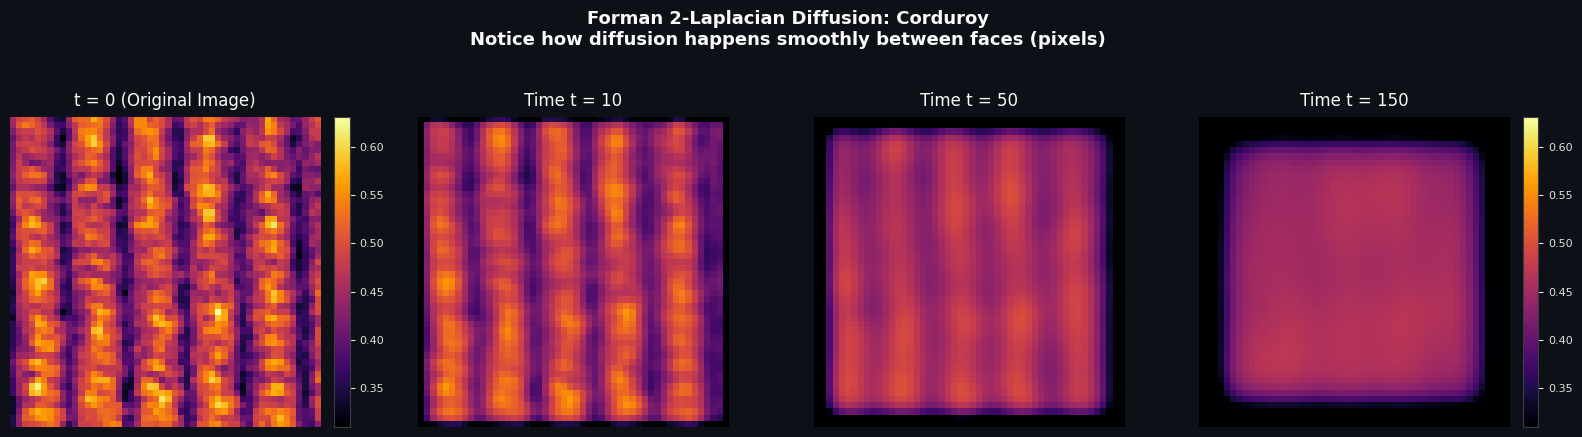

Computing Forman 2-Laplacian heat diffusion for:
Forman 2-Laplacian Diffusion: Sponge...
  - Calculating dense eigensystem (takes a few seconds)...


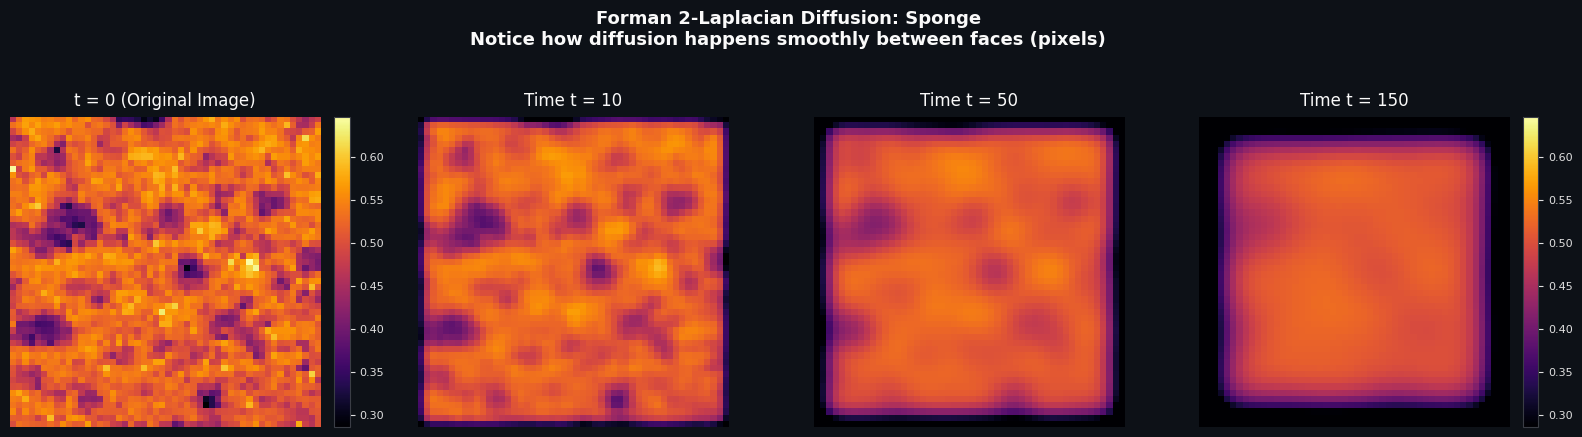

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.linalg import eigh

# ==========================================
# 1. בניית הלפלסיאן הדו-ממדי של פורמן (2-Laplacian)
# ==========================================

# ==========================================
# 2. סימולציית דיפוזיית חום ספקטרלית על פנים (Forman 2-Laplacian)
# ==========================================

def compute_forman_2_heat_diffusion(L2_sparse, img_pixels, H, W, c, times):
    """
    מבצע דיפוזיית חום ישירות על הפיקסלים (Faces).
    """
    # שלב א': חילוץ ערכים וקטורים עצמיים (Dense)
    print("  - Calculating dense eigensystem (takes a few seconds)...")
    L2_dense = L2_sparse.toarray()
    vals, vecs = eigh(L2_dense)

    # שלב ב': ב-2-Laplacian הפיקסלים הם הפנים, ולכן התמונה עצמה היא האות
    alpha = vecs.T @ img_pixels

    # שלב ג': דיפוזיה בזמן
    result_images = {}
    for t in times:
        # חום הפיקסלים (הפנים) בזמן t
        decay = np.exp(-c * t * vals)
        faces_t = vecs @ (decay * alpha)

        # התוצאה היא ישירות התמונה, אין צורך בשחזור!
        result_images[t] = faces_t.reshape((H, W))

    return result_images

def plot_forman_2_heat_diffusion(L2, img_path, title, H=50, W=50, c=0.05):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (W, H))
    pixels = img.flatten().astype(float) / 255.0

    times = [0, 10, 50, 150]

    print(f"Computing Forman 2-Laplacian heat diffusion for:\n{title}...")
    diff_snapshots = compute_forman_2_heat_diffusion(L2, pixels, H, W, c, times)

    # ציור
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle(title + "\nNotice how diffusion happens smoothly between faces (pixels)",
                 color='#fafafa', fontsize=13, fontweight='bold', y=1.08)

    for i, t in enumerate(times):
        ax = axes[i]
        phi_t_grid = diff_snapshots[t]

        # בניגוד ל-1-Laplacian, כאן אפשר להשתמש בנרמול קבוע כדי לראות את ההחלקה
        # התמונה לא "נמסה לאפס" אלא מתאזנת לממוצע.
        vmin, vmax = diff_snapshots[0].min(), diff_snapshots[0].max()

        im = ax.imshow(phi_t_grid, cmap='inferno', vmin=vmin, vmax=vmax, interpolation='nearest')

        title_str = f'Time t = {t}' if t > 0 else 't = 0 (Original Image)'
        ax.set_title(title_str, color='#fafafa', pad=8)
        ax.axis('off')

        # Colorbar
        if i == 0 or i == 3:
            cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cb.ax.yaxis.set_tick_params(color='#e0e0e0', labelsize=8)
            cb.outline.set_edgecolor('#3a3d45')
            plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color='#e0e0e0')

    plt.tight_layout()
    plt.show()

# ==========================================
# 3. הרצה
# ==========================================

KTH_ROOT = "/content/drive/My Drive/Final Project (Applied mathmatic)/KTH-TIPS"
img_smooth_path = f"{KTH_ROOT}/corduroy/42-scale_1_im_1_grey.png"
img_rough_path  = f"{KTH_ROOT}/sponge/21-scale_1_im_1_grey.png"

H_size, W_size = 50, 50

print("Building Forman 2-Laplacian matrix...")
L2_pure = build_forman_2_laplacian(H_size, W_size)

plot_forman_2_heat_diffusion(L2_pure, img_smooth_path, "Forman 2-Laplacian Diffusion: Corduroy", H=H_size, W=W_size)
plot_forman_2_heat_diffusion(L2_pure, img_rough_path,  "Forman 2-Laplacian Diffusion: Sponge", H=H_size, W=W_size)

##Forman 1D Laplacian on KTH-TIPS dataset

/tmp/ipykernel_2030/392774893.py:295: RuntimeWarning: k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.
  ev_smooth, _ = eigsh(forman_smooth, k=k, which='SM')
/tmp/ipykernel_2030/392774893.py:296: RuntimeWarning: k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.
  ev_rough,  _ = eigsh(forman_rough,  k=k, which='SM')


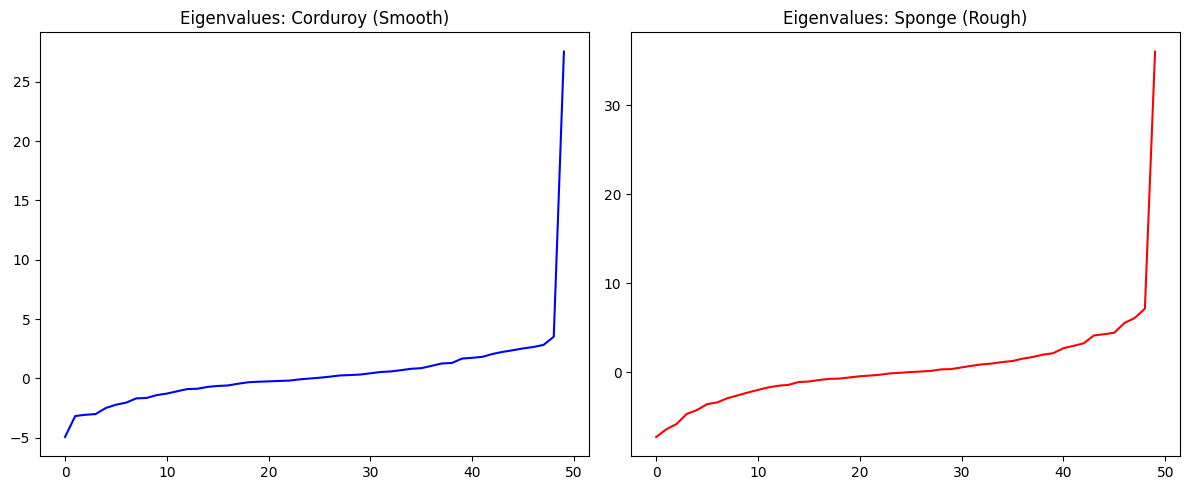

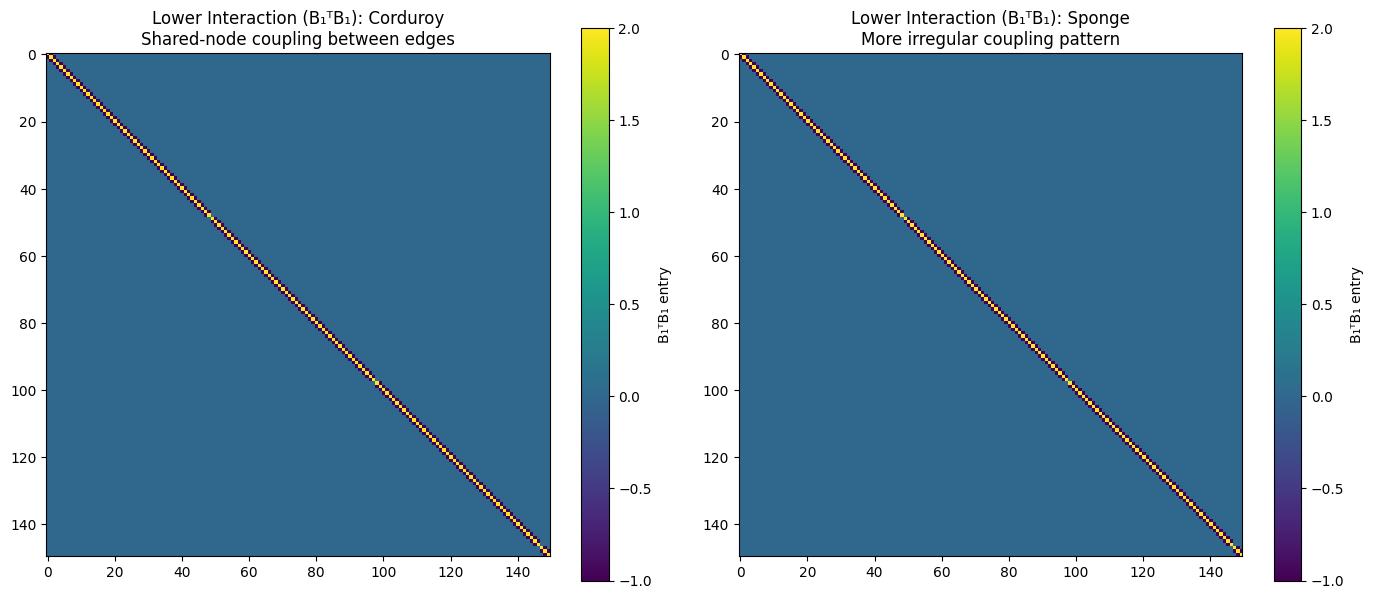

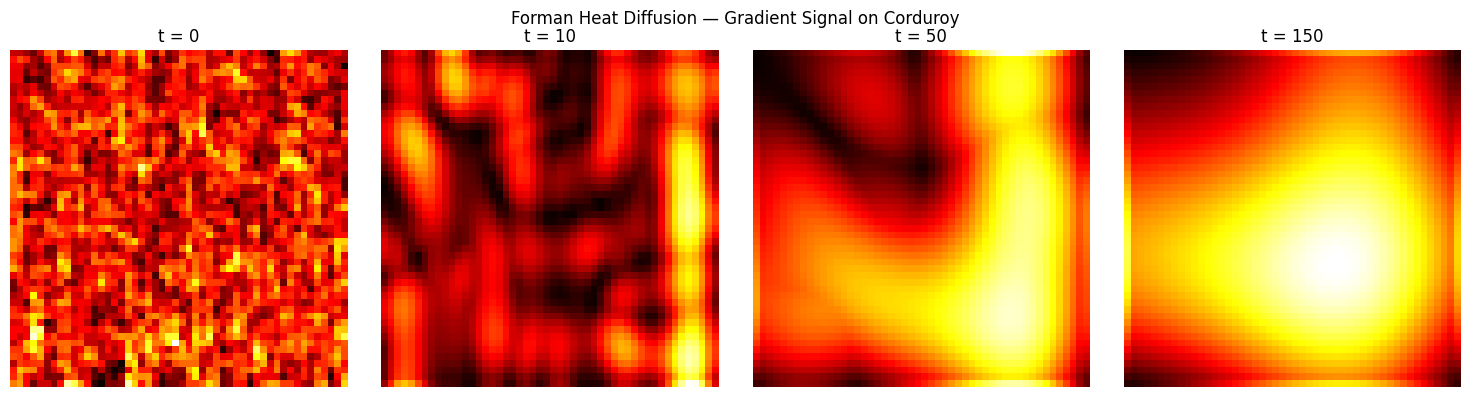

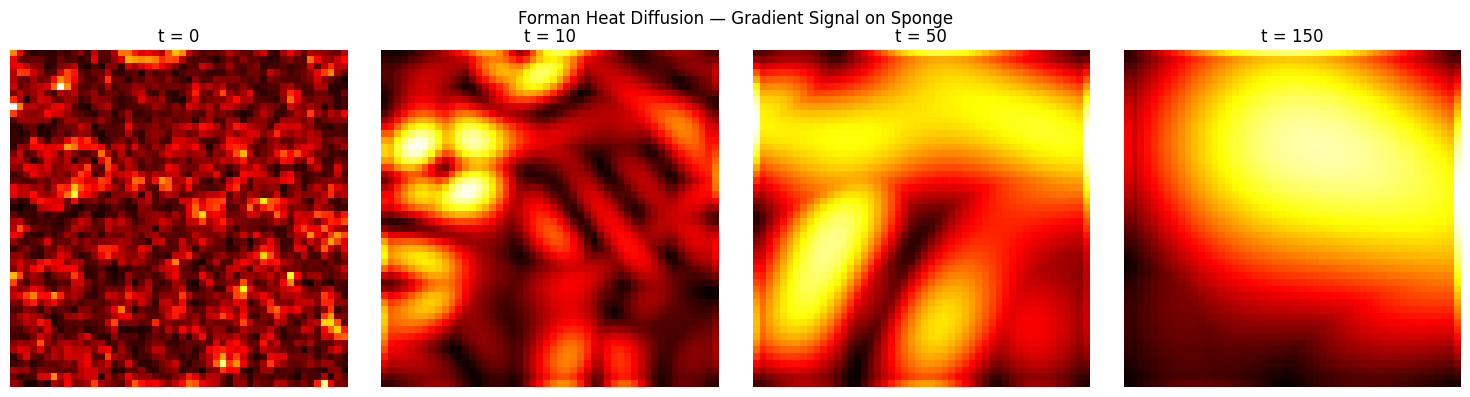

TypeError: build_forman_laplacian() got an unexpected keyword argument 'n_size'

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy.sparse import csr_matrix, lil_matrix, diags, eye
from scipy.sparse.linalg import eigsh, expm_multiply
from scipy.linalg import eigh
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
import xgboost as xgb
from scipy import sparse


# ============================================================
# SECTION 1: Core Forman 1-Laplacian Builder
#   L1 = B1.T @ B1  +  B2 @ B2.T
#
#   Cell complex on an (h x w) pixel grid:
#     0-cells (nodes)  : h*w
#     1-cells (edges)  : h*(w-1) horizontal + (h-1)*w vertical
#     2-cells (faces)  : (h-1)*(w-1) unit squares
#
#   Edge indexing:
#     Horizontal edge (y,x)->(y,x+1)  -> index  y*(w-1) + x
#     Vertical   edge (y,x)->(y+1,x)  -> index  h*(w-1) + y*w + x
# ============================================================

def build_forman_laplacian(img_path, n_size=50):
    """
    Build the Forman 1-Laplacian L1 = B1.T @ B1 + B2 @ B2.T
    for a grayscale image treated as a 2D cell complex.

    Returns
    -------
    L1          : sparse (num_edges x num_edges)
    img         : resized grayscale image array (h, w)
    edge_signal : gradient vector, one value per edge
    n_h         : number of horizontal edges
    n_v         : number of vertical edges
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image at {img_path}")
    img = cv2.resize(img, (n_size, n_size))
    h, w = img.shape
    pixels = img.astype(float) / 255.0

    n_h       = h * (w - 1)           # horizontal edge count
    n_v       = (h - 1) * w           # vertical edge count
    num_edges = n_h + n_v
    num_nodes = h * w
    num_faces = (h - 1) * (w - 1)

    def h_idx(y, x):    return y * (w - 1) + x          # horizontal edge
    def v_idx(y, x):    return n_h + y * w + x           # vertical edge
    def node_idx(y, x): return y * w + x
    def face_idx(y, x): return y * (w - 1) + x

    # ── B1 : edges -> nodes  (tail=-1, head=+1) ──────────────
    B1 = lil_matrix((num_nodes, num_edges), dtype=float)

    for y in range(h):
        for x in range(w - 1):                            # horizontal edges
            e    = h_idx(y, x)
            tail = node_idx(y, x)
            head = node_idx(y, x + 1)
            B1[tail, e] = -1.0
            B1[head, e] = +1.0

    for y in range(h - 1):
        for x in range(w):                                # vertical edges
            e    = v_idx(y, x)
            tail = node_idx(y, x)
            head = node_idx(y + 1, x)
            B1[tail, e] = -1.0
            B1[head, e] = +1.0

    B1 = B1.tocsr()

    # ── B2 : faces -> edges  (CCW orientation) ───────────────
    # Each face (y,x) is bounded by 4 edges:
    #   bottom h_edge(y,   x)   +1
    #   right  v_edge(y,   x+1) +1
    #   top    h_edge(y+1, x)   -1  (reversed orientation)
    #   left   v_edge(y,   x)   -1  (reversed orientation)
    B2 = lil_matrix((num_edges, num_faces), dtype=float)

    for y in range(h - 1):
        for x in range(w - 1):
            f = face_idx(y, x)
            B2[h_idx(y,     x    ), f] = +1.0   # bottom
            B2[v_idx(y,     x + 1), f] = +1.0   # right
            B2[h_idx(y + 1, x    ), f] = -1.0   # top  (reversed)
            B2[v_idx(y,     x    ), f] = -1.0   # left (reversed)

    B2 = B2.tocsr()

    # ── L1 = B1.T @ B1  +  B2 @ B2.T ────────────────────────
    L1 = B1.T @ B1 + B2 @ B2.T
    L1 = L1 + eye(num_edges) * 1e-6               # small regularisation

    # ── Edge signal: discrete gradient ───────────────────────
    # Each edge carries the intensity difference between its two endpoint pixels.
    # This is the natural 1-cochain (discrete derivative) of the image.
    edge_signal = np.zeros(num_edges)
    for y in range(h):
        for x in range(w - 1):
            edge_signal[h_idx(y, x)] = pixels[y, x + 1] - pixels[y, x]
    for y in range(h - 1):
        for x in range(w):
            edge_signal[v_idx(y, x)] = pixels[y + 1, x] - pixels[y, x]

    return L1, img, edge_signal, n_h, n_v

# ============================================================
# SECTION 2: Helper – project edge signal back to a 2D image
# ============================================================

def edge_signal_to_gradient_image(edge_signal, h, w):
    """
    Convert an edge-space signal vector back to a (h, w) gradient-magnitude
    image by averaging contributions from all edges adjacent to each pixel.
    """
    n_h = h * (w - 1)

    def h_idx(y, x): return y * (w - 1) + x
    def v_idx(y, x): return n_h + y * w + x

    grad_img = np.zeros((h, w))
    count    = np.zeros((h, w))

    for y in range(h):
        for x in range(w - 1):
            mag = abs(edge_signal[h_idx(y, x)])
            grad_img[y, x    ] += mag;  count[y, x    ] += 1
            grad_img[y, x + 1] += mag;  count[y, x + 1] += 1

    for y in range(h - 1):
        for x in range(w):
            mag = abs(edge_signal[v_idx(y, x)])
            grad_img[y,     x] += mag;  count[y,     x] += 1
            grad_img[y + 1, x] += mag;  count[y + 1, x] += 1

    count[count == 0] = 1
    return grad_img / count


# ============================================================
# SECTION 3: Visualisation on two KTH-TIPS images
# ============================================================

KTH_ROOT = "/content/drive/My Drive/Final Project (Applied mathmatic)/KTH-TIPS"
img_smooth_path = f"{KTH_ROOT}/corduroy/42-scale_1_im_1_grey.png"
img_rough_path  = f"{KTH_ROOT}/sponge/21-scale_1_im_1_grey.png"

L1_smooth, img_smooth, es_smooth, nh_s, nv_s = build_forman_laplacian(img_smooth_path)
L1_rough,  img_rough,  es_rough,  nh_r, nv_r = build_forman_laplacian(img_rough_path)



h, w = img_smooth.shape   # both 50x50

# ── Gradient magnitude maps ──────────────────────────────────
gm_smooth = edge_signal_to_gradient_image(es_smooth, h, w)
gm_rough  = edge_signal_to_gradient_image(es_rough,  h, w)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(gm_smooth, cmap='hot')
plt.title('Gradient Magnitude Map: Corduroy (Smooth)')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(gm_rough, cmap='hot')
plt.title('Gradient Magnitude Map: Sponge (Rough)')
plt.colorbar()
plt.tight_layout()
plt.show()


# ============================================================
# SECTION 4: Eigenvalue Comparison (Forman Spectral Signature)
# ============================================================

k = 100
ev_smooth, _ = eigsh(forman_smooth, k=k, which='SM')
ev_rough,  _ = eigsh(forman_rough,  k=k, which='SM')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
#plt.imshow(np.sort(ev_smooth))
plt.plot(np.sort(ev_smooth), 'b-', label='Corduroy (Smooth)')
plt.title('Eigenvalues: Corduroy (Smooth)')

plt.subplot(1, 2, 2)
#plt.imshow(np.sort(ev_rough))
plt.plot(np.sort(ev_rough),  'r-', label='Sponge (Rough)')
plt.title('Eigenvalues: Sponge (Rough)')
plt.tight_layout()
plt.show()




# ============================================================
# SECTION 5: Zoomed Weight Matrix (Lower Interaction B1.T @ B1)
# ============================================================

def get_forman_lower(img_path, n_size=50):
    """Return only B1.T @ B1 as a dense array for visualisation."""
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (n_size, n_size))
    h, w = img.shape
    n_h       = h * (w - 1)
    num_edges = n_h + (h - 1) * w
    num_nodes = h * w

    B1 = lil_matrix((num_nodes, num_edges), dtype=float)
    for y in range(h):
        for x in range(w - 1):
            e = y * (w - 1) + x
            B1[y * w + x,     e] = -1.0
            B1[y * w + x + 1, e] = +1.0
    for y in range(h - 1):
        for x in range(w):
            e = n_h + y * w + x
            B1[y * w + x,       e] = -1.0
            B1[(y + 1) * w + x, e] = +1.0
    B1 = B1.tocsr()
    return (B1.T @ B1).toarray()


lower_s = get_forman_lower(img_smooth_path)
lower_r = get_forman_lower(img_rough_path)
zoom    = 150

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(lower_s[:zoom, :zoom], cmap='viridis', interpolation='none')
plt.colorbar(label='B₁ᵀB₁ entry')
plt.title('Lower Interaction (B₁ᵀB₁): Corduroy\nShared-node coupling between edges')

plt.subplot(1, 2, 2)
plt.imshow(lower_r[:zoom, :zoom], cmap='viridis', interpolation='none')
plt.colorbar(label='B₁ᵀB₁ entry')
plt.title('Lower Interaction (B₁ᵀB₁): Sponge\nMore irregular coupling pattern')
plt.tight_layout()
plt.show()


# ============================================================
# SECTION 6: Heat Diffusion on the Edge (Gradient) Signal
# ============================================================

def simulate_heat_forman(L1, edge_signal, h, w, title, size=50):
    """
    Diffuse the gradient signal using the matrix exponential exp(-t L1).
    Unlike the 0-Laplacian which diffuses pixel intensities, here we
    diffuse the gradient vector — i.e. the topology of edges.
    """
    times = [0, 10, 50, 150]
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))

    for i, t in enumerate(times):
        if t == 0:
            ht = edge_signal.copy()
        else:
            ht = expm_multiply(-L1, edge_signal, start=0, stop=t, num=2)[-1]
        gm = edge_signal_to_gradient_image(ht, h, w)
        axes[i].imshow(gm, cmap='hot')
        axes[i].set_title(f't = {t}')
        axes[i].axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


simulate_heat_forman(L1_smooth, es_smooth, h, w,
                     'Forman Heat Diffusion — Gradient Signal on Corduroy')
simulate_heat_forman(L1_rough,  es_rough,  h, w,
                     'Forman Heat Diffusion — Gradient Signal on Sponge')


# ============================================================
# SECTION 7: Diffusion Matrix  P = row_normalise(L1)
# ============================================================

def plot_forman_diffusion_matrix(img_path, title, n_size=30):
    L1, _, _, _, _ = build_forman_laplacian(img_path, n_size=n_size)
    L1_arr  = L1.toarray()
    row_sums = L1_arr.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    P = L1_arr / row_sums

    plt.figure(figsize=(8, 8))
    plt.imshow(P[:100, :100], cmap='viridis')
    plt.colorbar(label='Diffusion Probability')
    plt.title(f'Forman Diffusion Matrix (P) — {title}\n(Zoomed 100×100 block)')
    plt.xlabel('Edge Index j')
    plt.ylabel('Edge Index i')
    plt.show()


plot_forman_diffusion_matrix(img_smooth_path, 'Corduroy (Smooth)')
plot_forman_diffusion_matrix(img_rough_path,  'Sponge (Rough)')


# ============================================================
# SECTION 8: Feature Extraction Functions
# ============================================================

def get_spectral_signature_forman(img_path, k=100):
    """
    Forman 1-Laplacian spectral signature.
    Returns k smallest eigenvalues of L1 (edge-space).
    Drop-in replacement for the original get_spectral_signature().
    """
    try:
        L1, _, _, _, _ = build_forman_laplacian(img_path, n_size=50)
        eigenvalues, _ = eigsh(L1, k=k, which='SM')
        return np.sort(eigenvalues)
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return None


def get_multiscale_signature_forman(img_path, k=50, n_size=64):
    """
    Multi-scale Forman spectral signature.
    Uses three image resolutions instead of three sigma values —
    coarse/medium/fine resolution sweeps the topological scale.
    Drop-in replacement for the original get_multiscale_signature().
    """
    resolutions = [32, 48, 64]
    all_features = []

    for res in resolutions:
        try:
            L1, _, _, _, _ = build_forman_laplacian(img_path, n_size=res)
            eigenvalues, _ = eigsh(L1, k=k, which='SM',
                                   maxiter=5000, ncv=3 * k)
            eigenvalues = np.sort(eigenvalues)
            stats = np.array([
                np.mean(eigenvalues),
                np.std(eigenvalues),
                np.median(eigenvalues),
                np.percentile(eigenvalues, 25),
                np.percentile(eigenvalues, 75),
                eigenvalues[1] if len(eigenvalues) > 1 else 0,   # Fiedler-like
            ])
            all_features.append(np.concatenate([eigenvalues, stats]))
        except Exception:
            try:
                L1_dense = L1.toarray()
                eigenvalues = eigh(L1_dense, subset_by_index=[0, k - 1],
                                   eigvals_only=True)
                eigenvalues = np.sort(eigenvalues)
                stats = np.array([
                    np.mean(eigenvalues), np.std(eigenvalues),
                    np.median(eigenvalues),
                    np.percentile(eigenvalues, 25),
                    np.percentile(eigenvalues, 75),
                    eigenvalues[1] if len(eigenvalues) > 1 else 0,
                ])
                all_features.append(np.concatenate([eigenvalues, stats]))
            except Exception:
                all_features.append(np.zeros(k + 6))

    return np.concatenate(all_features)   # 3 × (k + 6) features


def extract_forman_features(img_path, k=50, n_size=32):
    """
    Lightweight Forman 1-Laplacian features for the XGBoost pipeline.
    Returns k eigenvalues + 6 summary stats.
    Drop-in replacement for the original extract_spectral_features().
    """
    try:
        L1, _, _, _, _ = build_forman_laplacian(img_path, n_size=n_size)
        vals = eigsh(L1, k=k, which='SM', return_eigenvectors=False)
        vals = np.sort(vals)
    except Exception:
        vals = np.zeros(k)

    stats = [np.mean(vals), np.std(vals), np.median(vals),
             np.min(vals),  np.max(vals), np.ptp(vals)]
    return np.concatenate([vals, stats])


# ============================================================
# SECTION 9: Dataset Preparation with Cache (KTH-TIPS)
# ============================================================

def prepare_kth_with_cache(kth_root, k=50, n_size=64,
        cache_path="/content/drive/My Drive/Final Project (Applied mathmatic)/kth_forman_features.npz"):

    categories = sorted([d for d in os.listdir(kth_root)
                         if os.path.isdir(os.path.join(kth_root, d))])
    label_map  = {cat: i for i, cat in enumerate(categories)}

    all_image_paths = []
    for cat in categories:
        cat_path = os.path.join(kth_root, cat)
        for fname in os.listdir(cat_path):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_image_paths.append(os.path.join(cat, fname))

    X, y, processed_paths = [], [], []
    if os.path.exists(cache_path):
        data = np.load(cache_path, allow_pickle=True)
        X               = list(data['X'])
        y               = list(data['y'])
        processed_paths = list(data['processed_paths'])
        print(f"Resuming from cache: {len(X)} samples found.")

    remaining    = [p for p in all_image_paths if p not in processed_paths]
    expected_dim = (k + 6) * 3                  # 3 resolutions × (k + 6 stats)

    if remaining:
        print(f"Starting Forman feature extraction for {len(remaining)} images...")
        for i, rel_path in enumerate(remaining):
            if i % 10 == 0:
                print(f"  {i+1}/{len(remaining)}: {rel_path}")

            full_path = os.path.join(kth_root, rel_path)
            feat      = get_multiscale_signature_forman(full_path, k=k, n_size=n_size)
            cat_name  = rel_path.split(os.sep)[0]

            if feat is not None and len(feat) == expected_dim:
                X.append(feat)
                y.append(label_map[cat_name])
            else:
                X.append(np.zeros(expected_dim))
                y.append(label_map[cat_name])
            processed_paths.append(rel_path)

            if len(processed_paths) % 100 == 0:
                np.savez(cache_path,
                         X=np.array(X, dtype=float), y=np.array(y),
                         categories=np.array(categories),
                         processed_paths=np.array(processed_paths))
                print(f"  >>> Checkpoint saved at {len(processed_paths)} images.")

    np.savez(cache_path,
             X=np.array(X, dtype=float), y=np.array(y),
             categories=np.array(categories),
             processed_paths=np.array(processed_paths))

    return (torch.tensor(np.array(X, dtype=float), dtype=torch.float32),
            torch.tensor(y, dtype=torch.long),
            categories)


# ============================================================
# SECTION 10: Classical + Color Features (unchanged)
# ============================================================

def get_classical_features(img_path, n_size=64):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.zeros(26 + 10 + 32)
    img      = cv2.resize(img, (n_size, n_size))
    features = []

    # LBP
    try:
        lbp  = local_binary_pattern(img, P=24, R=3, method='uniform')
        hist, _ = np.histogram(lbp.ravel(), bins=26, range=(0, 26), density=True)
        features.append(hist)
    except Exception:
        features.append(np.zeros(26))

    # GLCM
    try:
        glcm = graycomatrix(img, distances=[1, 3],
                            angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                            levels=256, symmetric=True, normed=True)
        glcm_feats = []
        for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']:
            vals = graycoprops(glcm, prop)
            glcm_feats.extend([vals.mean(), vals.std()])
        features.append(np.array(glcm_feats))
    except Exception:
        features.append(np.zeros(10))

    # Gabor
    try:
        img_f      = img.astype(np.float32) / 255.0
        gabor_feats = []
        for freq in [0.1, 0.2, 0.3, 0.4]:
            for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
                kernel   = cv2.getGaborKernel((15, 15), sigma=3.0, theta=theta,
                                              lambd=1.0/freq, gamma=0.5, psi=0)
                filtered = cv2.filter2D(img_f, cv2.CV_32F, kernel)
                gabor_feats.extend([filtered.mean(), filtered.std()])
        features.append(np.array(gabor_feats))
    except Exception:
        features.append(np.zeros(32))

    return np.concatenate(features)   # 68 features


def get_color_features(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return np.zeros(6)
    hsv         = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    color_feats = []
    for i in range(3):
        ch = hsv[:, :, i]
        color_feats.extend([ch.mean() / 255.0, ch.std() / 255.0])
    return np.array(color_feats)


def get_classical_and_color_features(img_path, n_size=64):
    classical = get_classical_features(img_path, n_size=n_size)
    color     = get_color_features(img_path)
    return np.concatenate([classical, color])   # 74 features


# ============================================================
# SECTION 11: Cache Enrichment (Forman spectral + classical + color)
# ============================================================

def enrich_kth_cache_with_classical(
        kth_root,
        spectral_cache_path,
        enriched_cache_path,
        n_size=64):

    print("Loading Forman spectral cache...")
    data            = np.load(spectral_cache_path, allow_pickle=True)
    X_spectral      = data['X']
    y               = data['y']
    categories      = list(data['categories'])
    processed_paths = list(data['processed_paths'])

    spectral_dim     = X_spectral.shape[1]
    X_classical_list = []
    start_from       = 0

    if os.path.exists(enriched_cache_path):
        enriched = np.load(enriched_cache_path, allow_pickle=True)
        if 'X_combined' in enriched:
            total_combined = enriched['X_combined']
            if len(total_combined) > 0:
                X_classical_list = list(total_combined[:, spectral_dim:])
                start_from       = len(X_classical_list)
                print(f"Resuming from sample {start_from}")

    remaining = processed_paths[start_from:]
    if not remaining:
        print("All features already computed.")
        enriched = np.load(enriched_cache_path, allow_pickle=True)
        return enriched['X_combined'], y, categories

    print(f"Computing Classical + Color features for {len(remaining)} images...")
    for i, rel_path in enumerate(remaining):
        full_path = os.path.join(kth_root, rel_path)
        classical = get_classical_and_color_features(full_path, n_size=n_size)
        X_classical_list.append(classical)

        if (i + 1) % 500 == 0:
            cur = np.array(X_classical_list, dtype=float)
            np.savez(enriched_cache_path,
                     X_combined=np.concatenate([X_spectral[:len(cur)], cur], axis=1),
                     y=y, categories=np.array(categories),
                     processed_paths=np.array(processed_paths))
            done = start_from + i + 1
            print(f"   Checkpoint: {done}/{len(processed_paths)}")

    X_classical = np.array(X_classical_list, dtype=float)
    X_combined  = np.concatenate([X_spectral, X_classical], axis=1)
    print(f"\nMerge: Forman({spectral_dim}) + Classical+Color({X_classical.shape[1]}) "
          f"= {X_combined.shape[1]} features")

    np.savez(enriched_cache_path,
             X_combined=X_combined, y=y,
             categories=np.array(categories),
             processed_paths=np.array(processed_paths))
    return X_combined, y, categories


# ============================================================
# SECTION 12: Neural Network (unchanged architecture)
# ============================================================

class TextureSpectralNet(nn.Module):
    def __init__(self, input_size, num_classes=10):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)


# ============================================================
# SECTION 13: Confusion Matrix Helper
# ============================================================

def plot_confusion_matrix(model, test_loader, categories, device, title_prefix=''):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for bx, by in test_loader:
            bx, by = bx.to(device), by.to(device)
            preds  = model(bx).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(by.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    cm         = confusion_matrix(all_labels, all_preds)
    cm_norm    = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    short_names = [c[:12] for c in categories]

    fig, axes = plt.subplots(1, 2, figsize=(22, 10))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=short_names, yticklabels=short_names,
                ax=axes[0], linewidths=0.3)
    axes[0].set_title('Confusion Matrix (Counts)', fontsize=14)
    axes[0].set_xlabel('Predicted');  axes[0].set_ylabel('True')
    axes[0].tick_params(axis='x', rotation=45)

    sns.heatmap(cm_norm, annot=True, fmt='.0%', cmap='RdYlGn',
                xticklabels=short_names, yticklabels=short_names,
                ax=axes[1], linewidths=0.3, vmin=0, vmax=1)
    axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14)
    axes[1].set_xlabel('Predicted');  axes[1].set_ylabel('True')
    axes[1].tick_params(axis='x', rotation=45)

    overall_acc = 100 * np.diag(cm).sum() / cm.sum()
    plt.suptitle(f'{title_prefix}KTH-TIPS — {len(categories)} Categories '
                 f'| Accuracy: {overall_acc:.1f}%', fontsize=16)
    plt.tight_layout()
    plt.savefig('confusion_matrix_kth_forman.png', dpi=150, bbox_inches='tight')
    plt.show()

    per_class_acc = np.diag(cm_norm)
    print("\nTop 5 Best:")
    for i in np.argsort(per_class_acc)[::-1][:5]:
        print(f"  {categories[i]:<20} {per_class_acc[i]*100:.1f}%")
    print("\nTop 5 Worst:")
    for i in np.argsort(per_class_acc)[:5]:
        print(f"  {categories[i]:<20} {per_class_acc[i]*100:.1f}%")

    print("\n--- Classification Report ---")
    print(classification_report(all_labels, all_preds,
                                target_names=categories, digits=2))
    return cm, per_class_acc


# ============================================================
# SECTION 14: Full Neural Network Training Pipeline (KTH-TIPS)
# ============================================================

def train_model_kth(dataset_path, k=50, n_size=48, epochs=150):
    print(f"Image size: {n_size}x{n_size}")
    print("=== Phase 1: Forman Feature Extraction ===")

    cache_path = "/content/drive/My Drive/Final Project (Applied mathmatic)/kth_forman_features.npz"
    X, y, categories = prepare_kth_with_cache(dataset_path, k=k, n_size=n_size,
                                               cache_path=cache_path)

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X.numpy())
    X        = torch.tensor(X_scaled, dtype=torch.float32)

    num_classes = len(categories)
    feature_dim = X.shape[1]
    print(f"Samples: {len(X)} | Classes: {num_classes} | Features: {feature_dim}")

    X_tr, X_te, y_tr, y_te = train_test_split(
        X.numpy(), y.numpy(),
        test_size=0.2, random_state=42, stratify=y.numpy()
    )
    print(f"Train: {len(X_tr)} | Test: {len(X_te)}")

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr)),
        batch_size=64, shuffle=True
    )
    test_loader = DataLoader(
        TensorDataset(torch.tensor(X_te), torch.tensor(y_te)),
        batch_size=64, shuffle=False
    )

    device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    model     = TextureSpectralNet(feature_dim, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_acc, best_model_state = 0, None

    print("\n=== Phase 2: Training ===")
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()

        if (epoch + 1) % 10 == 0:
            model.eval()
            correct = total = 0
            with torch.no_grad():
                for bx, by in test_loader:
                    bx, by = bx.to(device), by.to(device)
                    preds   = model(bx).argmax(dim=1)
                    correct += (preds == by).sum().item()
                    total   += by.size(0)

            acc    = 100 * correct / total
            lr_now = optimizer.param_groups[0]['lr']

            if acc > best_acc:
                best_acc         = acc
                best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
                marker = " ◄ best"
            else:
                marker = ""

            print(f"Epoch {epoch+1:3d} | Loss: {total_loss/len(train_loader):.4f} "
                  f"| Acc: {acc:.1f}% | LR: {lr_now:.6f}{marker}")

    model.load_state_dict(best_model_state)
    save_path = "/content/drive/My Drive/Final Project (Applied mathmatic)/best_model_kth_forman.pt"
    torch.save({
        'model_state': best_model_state,
        'categories':  categories,
        'feature_dim': feature_dim,
        'best_acc':    best_acc
    }, save_path)

    print(f"\n{'='*45}")
    print(f"Best Test Accuracy:       {best_acc:.2f}%")
    print(f"Random baseline:          {100/num_classes:.2f}% (1/{num_classes})")
    print(f"Improvement over random:  {best_acc - 100/num_classes:.1f}pp")
    print(f"Model saved to: {save_path}")

    return model, categories, best_acc, test_loader, device


# ── Run neural net pipeline ───────────────────────────────────
dataset_path = "/content/drive/My Drive/Final Project (Applied mathmatic)/KTH-TIPS"
model, categories, best_acc, test_loader, device = train_model_kth(
    dataset_path, k=50, n_size=48, epochs=150
)
plot_confusion_matrix(model, test_loader, categories, device,
                      title_prefix='Forman 1-Laplacian + Neural Net — ')


# ============================================================
# SECTION 15: Neural Net with Combined Features
#             (Forman spectral + classical + color)
# ============================================================

kth_root        = "/content/drive/My Drive/Final Project (Applied mathmatic)/KTH-TIPS"
spectral_cache  = "/content/drive/My Drive/Final Project (Applied mathmatic)/kth_forman_features.npz"
enriched_cache  = "/content/drive/My Drive/Final Project (Applied mathmatic)/kth_forman_enriched.npz"

X_combined, y_combined, categories = enrich_kth_cache_with_classical(
    kth_root, spectral_cache, enriched_cache, n_size=64
)

data    = np.load(enriched_cache, allow_pickle=True)
X_np    = data['X_combined']
y_np    = data['y']

scaler  = StandardScaler()
X_tr_np, X_te_np, y_tr_np, y_te_np = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42, stratify=y_np
)
X_train = scaler.fit_transform(X_tr_np)
X_test  = scaler.transform(X_te_np)

feature_dim = X_train.shape[1]
num_classes = len(categories)
print(f"Train: {len(X_train)} | Test: {len(X_test)} | Features: {feature_dim}")

train_loader_comb = DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                  torch.tensor(y_tr_np)),
    batch_size=64, shuffle=True
)
test_loader_comb = DataLoader(
    TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                  torch.tensor(y_te_np)),
    batch_size=64, shuffle=False
)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_c   = TextureSpectralNet(feature_dim, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_c.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

best_acc_c, best_state_c = 0, None
print(f"\nDevice: {device}\n=== Training (Combined) ===")

for epoch in range(200):
    model_c.train()
    total_loss = 0
    for bx, by in train_loader_comb:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        loss = criterion(model_c(bx), by)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()

    if (epoch + 1) % 10 == 0:
        model_c.eval()
        correct = total = 0
        with torch.no_grad():
            for bx, by in test_loader_comb:
                bx, by  = bx.to(device), by.to(device)
                preds    = model_c(bx).argmax(dim=1)
                correct += (preds == by).sum().item()
                total   += by.size(0)
        acc    = 100 * correct / total
        lr_now = optimizer.param_groups[0]['lr']
        if acc > best_acc_c:
            best_acc_c  = acc
            best_state_c = {k: v.clone() for k, v in model_c.state_dict().items()}
            marker = " ◄ best"
        else:
            marker = ""
        print(f"Epoch {epoch+1:3d} | Loss: {total_loss/len(train_loader_comb):.4f} "
              f"| Acc: {acc:.1f}% | LR: {lr_now:.6f}{marker}")

model_c.load_state_dict(best_state_c)
torch.save({
    'model_state': best_state_c,
    'categories':  categories,
    'feature_dim': feature_dim,
    'best_acc':    best_acc_c,
}, "/content/drive/My Drive/Final Project (Applied mathmatic)/best_model_kth_forman_combined.pt")

print(f"\n{'='*45}")
print(f"Best Accuracy (combined): {best_acc_c:.2f}%")
print(f"Random baseline:          {100/num_classes:.2f}%")

plot_confusion_matrix(model_c, test_loader_comb, categories, device,
                      title_prefix='Forman + Classical + Color — ')


# ============================================================
# SECTION 16: XGBoost Pipeline
#             (Forman spectral + classical + color)
# ============================================================

def prepare_kth_dataset_forman(kth_root, k=50, n_size=32):
    """
    Build the full feature matrix for all KTH-TIPS images using
    Forman 1-Laplacian spectral features + classical + color.
    """
    all_features = []
    all_labels   = []
    categories   = sorted([d for d in os.listdir(kth_root)
                            if os.path.isdir(os.path.join(kth_root, d))])
    print(f"Found {len(categories)} categories: {categories}")

    for idx, cat in enumerate(categories):
        cat_path  = os.path.join(kth_root, cat)
        img_files = (glob.glob(os.path.join(cat_path, "*.png")) +
                     glob.glob(os.path.join(cat_path, "*.jpg")))
        print(f"  Processing {cat:<20} | Images: {len(img_files)}")

        for img_p in img_files:
            try:
                spec  = extract_forman_features(img_p, k=k, n_size=n_size)
                extra = get_classical_and_color_features(img_p)
                all_features.append(np.concatenate([spec, extra]))
                all_labels.append(idx)
            except Exception:
                continue

    return np.array(all_features), np.array(all_labels), categories


# ── Run XGBoost ───────────────────────────────────────────────
kth_path = "/content/drive/My Drive/Final Project (Applied mathmatic)/KTH-TIPS"
X_kth, y_kth, kth_cats = prepare_kth_dataset_forman(kth_path)

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_kth, y_kth, test_size=0.2, random_state=42, stratify=y_kth
)

clf = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.7,
    tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    early_stopping_rounds=50,
    objective='multi:softprob',
    random_state=42
)
clf.fit(X_train_xgb, y_train_xgb,
        eval_set=[(X_test_xgb, y_test_xgb)], verbose=100)

xgb_acc = accuracy_score(y_test_xgb, clf.predict(X_test_xgb))
print(f"\nKTH-TIPS XGBoost Accuracy (Forman + Classical + Color): {xgb_acc*100:.2f}%")


# ── XGBoost Confusion Matrix ──────────────────────────────────
def plot_confusion_matrix_xgboost(model, X_test, y_test, categories):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)

    row_sums  = cm.sum(axis=1, keepdims=True)
    cm_norm   = np.zeros_like(cm, dtype=float)
    nz        = row_sums.flatten() != 0
    cm_norm[nz] = cm[nz].astype(float) / row_sums[nz]

    short_names = [c[:12] for c in categories]
    fig, axes   = plt.subplots(1, 2, figsize=(22, 10))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=short_names, yticklabels=short_names,
                ax=axes[0], linewidths=0.3)
    axes[0].set_title('Confusion Matrix (Counts)', fontsize=14)
    axes[0].set_xlabel('Predicted');  axes[0].set_ylabel('True')
    axes[0].tick_params(axis='x', rotation=45)

    sns.heatmap(cm_norm, annot=True, fmt='.0%', cmap='RdYlGn',
                xticklabels=short_names, yticklabels=short_names,
                ax=axes[1], linewidths=0.3, vmin=0, vmax=1)
    axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14)
    axes[1].set_xlabel('Predicted');  axes[1].set_ylabel('True')
    axes[1].tick_params(axis='x', rotation=45)

    overall_acc = 100 * np.diag(cm).sum() / cm.sum()
    plt.suptitle(f'XGBoost + Forman 1-Laplacian — KTH-TIPS '
                 f'{len(categories)} Categories | Accuracy: {overall_acc:.1f}%',
                 fontsize=16)
    plt.tight_layout()
    plt.savefig('confusion_matrix_kth_forman_xgboost.png', dpi=150, bbox_inches='tight')
    plt.show()

    per_class_acc = np.array([cm_norm[i, i] for i in range(len(categories))])
    print("\nTop 5 Best:")
    for i in np.argsort(per_class_acc)[::-1][:5]:
        print(f"  {categories[i]:<20} {per_class_acc[i]*100:.1f}%")
    print("\nTop 5 Worst:")
    for i in np.argsort(per_class_acc)[:5]:
        print(f"  {categories[i]:<20} {per_class_acc[i]*100:.1f}%")

    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred,
                                target_names=categories, digits=2))
    return cm, per_class_acc


plot_confusion_matrix_xgboost(clf, X_test_xgb, y_test_xgb, kth_cats)